# Исследование: patch-признаки, fine-tuning и ансамбли

Исторический рабочий ноутбук с кодом и сохранёнными результатами. Здесь оставлены переборы, промежуточные проверки и неудачные варианты. Финальный воспроизводимый сценарий находится в `mesh_quality.ipynb`. Для повторения исторических запусков нужны исходные данные и исследовательские checkpoints; они не входят в архив финальных весов.

# Исследовательская лаборатория качества 3D-мешей

Отдельный ноутбук экспериментов. Основной `mesh_quality.ipynb` не изменяется.

**Цель:** проверить гипотезы о локальных признаках, объединении ракурсов и адаптации DINOv2. Достижение 15.5 не гарантируется. Исходный контроль: trial 11, score платформы 12.8114; это не целевая метрика для автоматического поиска.

**Протокол:** одни и те же группы и разбиения; выбор эпохи по weighted AP на inner_valid; F1 после перекрёстного подбора порогов — дополнительная диагностика. После фиксации конфигурации — refit на 5970, пороги на прежней calibration, ограниченный аудит на check. Quality всегда равна отсутствию предсказанных дефектов. Отдельная quality-голова используется только для обучения.

Приложенный исследовательский обзор содержит гипотезы, а не доказательство, что логическое правило качества или отсутствие сглаживания нормалей являются ошибками. Здесь эти свойства не меняются скрыто.

### Как запускать
1. Используйте ядро `.venv` проекта. Выполняйте сверху вниз.
2. Настройки объёма работы находятся в одном блоке. По умолчанию включены новые признаки и fine-tuning; CPU-рендер всех мешей выключен как особо дорогой этап, но полностью реализован и включается одним флагом.
3. Кэши и запуски возобновляются после прерывания. Не запускайте одновременно две копии ноутбука с одинаковыми настройками.
4. Не используйте `check` для повторного выбора архитектур. Визуальный анализ её ошибок — описание результата, не разрешение подстраивать параметры.

Номера видов 0–5 обозначают порядок в PNG; их нельзя автоматически называть front/back для всех объектов.

## 1. Библиотеки и доступ к проекту
Установка запускается только если нужной библиотеки нет. Уже установленный PyTorch не переустанавливается. Для сравнимости среда каждого запуска сохраняется; смешивать результаты разных версий без проверки нельзя.

В Colab загрузите архив проекта в `/content` или примонтируйте Google Drive. Нужны `train.csv`, `train/`, `outputs/splits_seed_42.csv`, указанные checkpoint и global-кэши. Публичной ссылки на датасет у нас нет, поэтому ноутбук не притворяется, что может скачать закрытые данные автоматически. Можно задать `MESH_PROJECT_ARCHIVE_URL` в окружении для доступного ZIP.

In [22]:
import importlib.util, subprocess, sys, os
requirements = {
    'torch': 'torch>=2.3', 'torchvision': 'torchvision>=0.18',
    'timm': 'timm>=1.0.20,<2', 'numpy': 'numpy>=1.26',
    'pandas': 'pandas>=2.2', 'sklearn': 'scikit-learn>=1.5',
    'PIL': 'Pillow>=10', 'tqdm': 'tqdm>=4.66', 'matplotlib': 'matplotlib>=3.8',
}
missing=[spec for module,spec in requirements.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print(f'''Python: {sys.version}
Установлено дополнительных пакетов: {len(missing)}
''')

Python: 3.12.14 (main, Sep  1 2026, 14:09:38) [Clang 22.1.3 ]
Установлено дополнительных пакетов: 0



In [23]:
from pathlib import Path
import zipfile, urllib.request
project_candidates = [Path.cwd(), Path('/content/Sber_AI_Major_Task'), Path('/content/drive/MyDrive/Sber_AI_Major_Task')]
archive_url=os.environ.get('MESH_PROJECT_ARCHIVE_URL')
if archive_url and not any((p/'train.csv').exists() for p in project_candidates):
    archive=Path('/content/mesh_project.zip')
    urllib.request.urlretrieve(archive_url, archive)
    dest=Path('/content').resolve()
    with zipfile.ZipFile(archive) as z:
        for name in z.namelist():
            if not (dest/name).resolve().is_relative_to(dest):raise ValueError('Unsafe ZIP member')
        z.extractall(dest)
PROJECT_ROOT = next((p for p in project_candidates if (p/'train.csv').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Откройте ноутбук из папки проекта или разместите архив проекта в /content/Sber_AI_Major_Task.')
print(f'''Проект: {PROJECT_ROOT}
''')

Проект: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task



## 2. Общие функции, источники данных и возобновляемый кэш
Patch-токены сохраняются float16 на диск и читаются по объектам через memmap, а не целиком в RAM. При 224: 6×256×384 значений на объект, около 9.85 GiB для 8964 объектов; при 336 — около 22.16 GiB. Это дополнительный диск, не размер GPU batch. Кэш считается готовым только после записи данных. Проверяется исходный checkpoint, ID, разрешение и версия timm.

Глобальный baseline использует исходные float32 признаки. Для patch-эксперимента при 224 глобальная часть остаётся той же; меняется только добавление локальных токенов.

In [24]:
import os, sys, json, hashlib, random, gc, math, shutil, time, copy
from pathlib import Path
from contextlib import nullcontext
from dataclasses import dataclass, asdict, replace
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import timm
from sklearn.metrics import f1_score, average_precision_score
from sklearn.model_selection import GroupKFold
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

DEFECTS = ['abstract','artifacts','intersection','lowpoly','noisy','open','partial','scale','set','simple']
TARGETS = DEFECTS + ['quality']

def digest(path):
    with open(path, 'rb') as f:
        return hashlib.file_digest(f, 'sha256').hexdigest()

def canonical_hash(obj):
    return hashlib.sha256(json.dumps(obj,sort_keys=True,ensure_ascii=False).encode()).hexdigest()

def save_json(path, obj):
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    tmp=path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(obj,ensure_ascii=False,indent=2),encoding='utf-8');tmp.replace(path)

def seed_all(seed):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():torch.mps.manual_seed(seed)
    torch.backends.cudnn.benchmark=False
    torch.backends.cudnn.deterministic=True

def sync(device):
    if device.type=='cuda':torch.cuda.synchronize(device)
    elif device.type=='mps':torch.mps.synchronize()

def release():
    gc.collect()
    if torch.cuda.is_available():torch.cuda.empty_cache()
    if torch.backends.mps.is_available():torch.mps.empty_cache()

def scores(y, p, thresholds=.5, ranking=True):
    y=np.asarray(y);p=np.asarray(p)
    assert y.shape==(len(p),11) and p.shape[1]==10 and len(p)>0
    assert np.isfinite(p).all()
    pred=p>=thresholds; q=~pred.any(1)
    qf=f1_score(y[:,10],q,zero_division=0)
    df=f1_score(y[:,:10],pred,average='weighted',zero_division=0)
    result={'f1_quality':float(qf),'f1_defects_weighted':float(df),'f1_final':float(10*(qf+df)),
            'good_rejected':int(((y[:,10]==1)&~q).sum()),'bad_accepted':int(((y[:,10]==0)&q).sum())}
    if ranking:
        result['weighted_ap']=float(average_precision_score(y[:,:10],p,average='weighted'))
    return result

def tune_thresholds(y, p, passes=5):
    # Vectorized F1 updates: AP is never recomputed inside threshold search.
    y=np.asarray(y);p=np.asarray(p);truth=y[:,:10].astype(bool)
    support=truth.sum(0).astype(float);weights=support/support.sum()
    grid=np.unique(np.r_[np.geomspace(.001,.1,25),np.arange(1,100)/100,.5])
    t=np.full(10,.5);pred=p>=t;history=[]
    def defect_f1(pred):
        tp=(pred&truth).sum(0);return np.divide(2*tp,support+pred.sum(0),out=np.zeros(10),where=(support+pred.sum(0))>0)
    best=scores(y,p,t,False)['f1_final']
    for pass_id in range(passes):
        changed=False
        for j in range(10):
            candidates=p[:,j,None]>=grid[None,:]
            other=np.delete(pred,j,axis=1).any(1)
            q=~(other[:,None]|candidates);qy=y[:,10].astype(bool)
            tpq=(q&qy[:,None]).sum(0);denq=q.sum(0)+qy.sum()
            qf=np.divide(2*tpq,denq,out=np.zeros(len(grid)),where=denq>0)
            tp=(candidates&truth[:,j,None]).sum(0);den=support[j]+candidates.sum(0)
            cf=np.divide(2*tp,den,out=np.zeros(len(grid)),where=den>0)
            f=defect_f1(pred);base=float(np.dot(weights,f)-weights[j]*f[j])
            values=10*(qf+base+weights[j]*cf)
            ix=int(values.argmax())
            if values[ix]>best+1e-12:
                old=t[j];t[j]=grid[ix];pred[:,j]=candidates[:,ix];best=float(values[ix]);changed=True
                history.append({'pass':pass_id+1,'defect':DEFECTS[j],'old':old,'threshold':t[j],'f1_final':best})
        if not changed:break
    return t,pd.DataFrame(history)

@dataclass(frozen=True)
class Experiment:
    name: str
    head: str='global'
    resolution: int=224
    loss: str='bce'
    quality: bool=False
    consistency: float=0.
    adaptation: str='frozen'
    epochs: int=20
    lr: float=0.0004918226353573444
    backbone_lr: float=1e-5
    weight_decay: float=0.0007023866368536486
    dropout: float=0.4348349614821148
    hidden: int=256
    microbatch: int=4
    effective_batch: int=16
    quality_weight: float=.2
    lora_rank: int=4
    lora_blocks: int=2
    view_topk: int=2
    special_views: bool=False

class Context:
    def __init__(self,root,device=None):
        self.root=Path(root).resolve()
        self.device=torch.device(device or ('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'))
        self.source=self.root/'checkpoints/dinov2_weighted_ap_20260917_113030/best_model.pt'
        self.pair=self.root/'checkpoints/two_heads_class_blend_20260917_132101_468006'
        self.cache_dir=self.source.parent/'feature_cache'
        self.out=self.root/'outputs/research_lab';self.out.mkdir(parents=True,exist_ok=True)
        self.table=pd.read_csv(self.root/'train.csv',dtype={'item_id':str}).set_index('item_id')
        assert list(self.table.columns)==TARGETS and self.table.index.is_unique
        assert np.array_equal(self.table.quality.to_numpy(),(~self.table[DEFECTS].to_numpy().any(1)).astype(int))
        self.source_hash=digest(self.source)
        self.source_checkpoint=torch.load(self.source,map_location='cpu',weights_only=True)
        self.image_config=self.source_checkpoint['config']
        self.globals={};self.ids={}
        for name in ['train','valid']:
            c=torch.load(self.cache_dir/f'{name}.pt',map_location='cpu',weights_only=True)
            assert c['metadata']['checkpoint_sha256']==self.source_hash
            self.ids[name]=list(c['item_ids']);self.globals.update(zip(c['item_ids'],c['features']))
            np.testing.assert_array_equal(c['targets'].numpy(),self.table.loc[c['item_ids'],TARGETS].to_numpy())
        split=pd.read_csv(self.cache_dir/'optuna_inner_split.csv',dtype={'item_id':str}).set_index('item_id')
        groups=pd.read_csv(self.root/'outputs/splits_seed_42.csv',dtype={'item_id':str}).set_index('item_id')
        self.groups=groups.group_id
        self.ids['inner_train']=split.index[split.search_part=='inner_train'].tolist()
        self.ids['inner_valid']=split.index[split.search_part=='inner_valid'].tolist()
        pair=json.loads((self.pair/'experiment.json').read_text())
        self.ids['calibration']=pair['calibration_item_ids'];self.ids['check']=pair['check_item_ids']
        assert set(self.ids['inner_train'])|set(self.ids['inner_valid'])==set(self.ids['train'])
        assert set(self.ids['calibration'])|set(self.ids['check'])==set(self.ids['valid'])
        for a,b in [('inner_train','inner_valid'),('train','valid'),('calibration','check')]:
            assert set(self.ids[a]).isdisjoint(self.ids[b])
            assert set(self.groups.loc[self.ids[a]]).isdisjoint(self.groups.loc[self.ids[b]])
        self.all_ids=self.ids['train']+self.ids['valid'];self.rows={s:i for i,s in enumerate(self.all_ids)}
        assert len(set(self.all_ids))==len(self.all_ids)==len(self.table)
        self.protocol_hash=canonical_hash({'source':self.source_hash,'ids':self.ids,'targets':self.table.loc[self.all_ids,TARGETS].to_numpy().tolist()})
        self._stores={}
    def labels(self,ids):return self.table.loc[ids,TARGETS].to_numpy(dtype=np.float32)
    def backbone(self):
        m=timm.create_model(self.image_config['model_name'],pretrained=False,num_classes=0,img_size=224,dynamic_img_size=True)
        m.load_state_dict({k.removeprefix('backbone.'):v for k,v in self.source_checkpoint['model_state_dict'].items() if k.startswith('backbone.')},strict=True)
        return m
    def transform(self,resolution):
        return transforms.Compose([transforms.Resize((resolution,resolution),interpolation=transforms.InterpolationMode.BICUBIC,antialias=True),transforms.ToTensor(),transforms.Normalize(self.image_config['image_mean'],self.image_config['image_std'])])
    def images(self,item,resolution):
        with Image.open(self.root/'train'/f'{item}.png') as im:im=im.convert('RGB')
        w,h=im.size;assert w%3==0 and h%2==0 and w//3==h//2
        tf=self.transform(resolution)
        return torch.stack([tf(im.crop((c*w//3,r*h//2,(c+1)*w//3,(r+1)*h//2))) for r in range(2) for c in range(3)])

class TokenStore:
    def __init__(self,ctx,resolution):
        self.ctx=ctx;self.resolution=resolution;self.n=(resolution//14)**2
        self.path=ctx.out/'tokens'/f'r{resolution}_{ctx.source_hash[:12]}'
        self.path.mkdir(parents=True,exist_ok=True)
        meta={'ids':ctx.all_ids,'resolution':resolution,'source_sha256':ctx.source_hash,'dtype':'float16','tokens':self.n,'channels':384,'schema':1,'normalization':ctx.image_config['image_mean'],'std':ctx.image_config['image_std'],'timm':timm.__version__}
        mp=self.path/'manifest.json'
        if mp.exists():assert json.loads(mp.read_text())==meta,'Cache metadata mismatch'
        else:save_json(mp,meta)
        shapes={'global':(len(ctx.all_ids),6,384),'patch':(len(ctx.all_ids),6,self.n,384),'ready':(len(ctx.all_ids),)}
        missing=sum(int(np.prod(shape))*(1 if k=='ready' else 2) for k,shape in shapes.items() if not (self.path/f'{k}.npy').exists())
        if shutil.disk_usage(self.path).free<missing+2*1024**3:raise RuntimeError(f'Need {missing/1024**3:.1f} GiB + 2 GiB free for cache')
        for name,shape in shapes.items():
            path=self.path/f'{name}.npy';exists=path.exists()
            arr=np.lib.format.open_memmap(path,mode='r+' if exists else 'w+',dtype=np.bool_ if name=='ready' else np.float16,shape=shape)
            assert arr.shape==shape
            if name=='ready' and not exists:arr[:]=False;arr.flush()
            setattr(self,name,arr)
    def ensure(self,ids):
        todo=[s for s in ids if not self.ready[self.ctx.rows[s]]]
        if not todo:return
        model=self.ctx.backbone().to(self.ctx.device).eval();model.requires_grad_(False)
        with torch.inference_mode():
            for item in tqdm(todo,desc=f'Tokens {self.resolution}'):
                x=self.ctx.images(item,self.resolution).to(self.ctx.device)
                # Three views at a time keep 336px extraction within T4 memory.
                tokens=torch.cat([model.forward_features(x[j:j+3]) for j in range(0,6,3)])
                row=self.ctx.rows[item];patch=tokens[:,model.num_prefix_tokens:]
                assert patch.shape==(6,self.n,384)
                getattr(self,'global')[row]=tokens[:,0].cpu().numpy().astype(np.float16)
                self.patch[row]=patch.cpu().numpy().astype(np.float16)
                getattr(self,'global').flush();self.patch.flush()
                self.ready[row]=True;self.ready.flush()
        del model;release()

def token_store(ctx,resolution):
    if resolution not in ctx._stores:ctx._stores[resolution]=TokenStore(ctx,resolution)
    return ctx._stores[resolution]

def needs_patch(cfg):return cfg.head in ('patch_mean','patch_max','patch_attention','patch_only')

class LabDataset(Dataset):
    def __init__(self,ctx,ids,cfg):self.ctx=ctx;self.ids=list(ids);self.cfg=cfg;self.y=ctx.labels(ids)
    def __len__(self):return len(self.ids)
    def __getitem__(self,i):
        item=self.ids[i];cfg=self.cfg;out={'targets':torch.from_numpy(self.y[i]),'item_id':item}
        if cfg.adaptation!='frozen':out['images']=self.ctx.images(item,cfg.resolution)
        else:
            if cfg.resolution==224:out['global']=self.ctx.globals[item].clone()
            else:
                st=token_store(self.ctx,cfg.resolution);row=self.ctx.rows[item];assert st.ready[row]
                out['global']=torch.from_numpy(np.array(getattr(st,'global')[row],dtype=np.float32))
            if needs_patch(cfg):
                st=token_store(self.ctx,cfg.resolution);row=self.ctx.rows[item];assert st.ready[row]
                out['patch']=torch.from_numpy(np.array(st.patch[row],dtype=np.float32))
            if cfg.head=='render':out['render']=torch.from_numpy(np.load(self.ctx.out/'renders'/f'{item}.npy',allow_pickle=False))
        return out

def prepare(ctx,ids,cfg):
    if cfg.adaptation=='frozen' and (needs_patch(cfg) or cfg.resolution!=224):token_store(ctx,cfg.resolution).ensure(ids)
    if cfg.head=='render':ensure_renders(ctx,ids)


In [25]:
CTX = Context(PROJECT_ROOT)
seed_all(42)
# Число потоков CPU ограничено, чтобы не конкурировать с MPS за все ядра.
torch.set_num_threads(min(8, os.cpu_count() or 1))
environment={'python':sys.version,'torch':str(torch.__version__),'timm':timm.__version__,'numpy':np.__version__,'pandas':pd.__version__,'device':str(CTX.device),'protocol_hash':CTX.protocol_hash}
save_json(CTX.out/'environment.json',environment)
print(f'''Устройство: {CTX.device}
Inner train: {len(CTX.ids['inner_train'])}
Inner valid: {len(CTX.ids['inner_valid'])}
Full train: {len(CTX.ids['train'])}
Calibration: {len(CTX.ids['calibration'])}
Check: {len(CTX.ids['check'])}
Результаты: {CTX.out}
''')

Устройство: mps
Inner train: 4775
Inner valid: 1195
Full train: 5970
Calibration: 1496
Check: 1498
Результаты: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/research_lab



## 3. Модели, функции потерь и единый цикл обучения

- **Global:** точная структура головы trial 11 (LayerNorm → 256 → GELU → dropout → 10).
- **View-aware:** обучаемая позиция ракурса, shared/class attention, top-1/top-2 и отдельная заранее фиксированная гипотеза для partial/open/scale. Это сравнительные контроли, не обещание улучшить прежний attention.
- **Patch:** mean, max, class attention и patch-only. Пространственные позиции уже присутствуют в DINOv2; отдельный Transformer на 1536 токенах не создаётся.
- **Fine-tuning:** последний LayerNorm, последние 1/2 блока, собственная pure-PyTorch LoRA для qkv/proj последних двух блоков. CUDA-only расширений нет. Голова начинается с нуля; веса головы, обученной на inner_valid, в эксперимент не попадают.
- **Quality:** вспомогательная BCE и необязательная слабая consistency. Произведение вероятностей — мягкий суррогат с предположением независимости, не точная вероятность хорошего объекта.
- **ASL:** positive gamma=0, negative gamma=4, clipping=.05; проверяется отдельно от смены архитектуры.

CUDA использует AMP, MPS — float32. Эффективный batch=16; уменьшение microbatch не меняет нормировку последнего неполного шага. Резюме сохраняется после каждой эпохи. Смена версии кода требует нового `CODE_VERSION`, чтобы не продолжить несовместимый эксперимент.

In [26]:
class LabHead(nn.Module):
    def __init__(self,cfg,dim=384,classes=10,views=6):
        super().__init__();self.cfg=cfg;self.dim=dim;self.classes=classes
        self.view_position=nn.Parameter(torch.zeros(1,views,dim)) if cfg.head.startswith('view') else None
        self.projection=nn.Sequential(nn.LayerNorm(dim),nn.Linear(dim,128),nn.GELU()) if cfg.head!='global' else None
        self.attention=nn.Linear(128,1 if cfg.head=='view_shared' else classes) if cfg.head in ('view_shared','view_class','view_topk','patch_attention','patch_only') else None
        self.local_classifier=nn.Parameter(torch.empty(classes,128)) if cfg.head=='view_topk' else None
        if self.local_classifier is not None:nn.init.normal_(self.local_classifier,std=.02)
        extra=0 if cfg.head=='global' else 128
        if cfg.head=='render':
            self.render_cnn=nn.Sequential(nn.Conv2d(5,24,3,padding=1),nn.GELU(),nn.MaxPool2d(2),nn.Conv2d(24,48,3,padding=1),nn.GELU(),nn.MaxPool2d(2),nn.Conv2d(48,128,3,padding=1),nn.GELU(),nn.AdaptiveAvgPool2d(1))
        self.fusion=nn.Sequential(nn.LayerNorm(2*dim+extra),nn.Linear(2*dim+extra,cfg.hidden),nn.GELU(),nn.Dropout(cfg.dropout))
        self.defect_head=nn.Linear(cfg.hidden,classes)
        self.quality_head=nn.Linear(cfg.hidden,1) if cfg.quality else None
        self.last_attention=None
    def forward(self,batch,explain=False):
        g=batch['global'];pooled=torch.cat([g.mean(1),g.amax(1)],-1);local=None;class_local=None
        if self.cfg.head.startswith('view'):
            tokens=self.projection(g+self.view_position)
        elif needs_patch(self.cfg):
            tokens=self.projection(batch['patch'].flatten(1,2))
        elif self.cfg.head=='render':
            r=batch['render'];b,v,c,h,w=r.shape
            local=self.render_cnn(r.reshape(b*v,c,h,w)).reshape(b,v,128).mean(1)
        if self.cfg.head in ('view_shared','view_class','view_topk','patch_attention','patch_only'):
            a=self.attention(tokens).softmax(dim=1)
            if explain:self.last_attention=a.detach().cpu()
            if a.shape[-1]==1:local=(a*tokens).sum(1)
            else:
                class_local=torch.einsum('btc,btd->bcd',a,tokens)
        elif self.cfg.head=='patch_mean':local=tokens.mean(1)
        elif self.cfg.head=='patch_max':local=tokens.amax(1)
        if self.cfg.head=='patch_only':pooled=torch.zeros_like(pooled)
        if class_local is not None:
            common=pooled[:,None,:].expand(-1,self.classes,-1)
            representation=self.fusion(torch.cat([common,class_local],-1))
            logits=(representation*self.defect_head.weight[None,:,:]).sum(-1)+self.defect_head.bias
            quality_repr=representation.mean(1)
            if self.cfg.head=='view_topk':
                instance_logits=torch.einsum('bvd,cd->bvc',tokens,self.local_classifier)
                top=instance_logits.topk(self.cfg.view_topk,dim=1).values.mean(1)
                if self.cfg.special_views:
                    # Predeclared class-specific hypothesis, never chosen on outer check.
                    top=top.clone()
                    for j in [DEFECTS.index('partial'),DEFECTS.index('open')]:top[:,j]=instance_logits[:,:,j].amax(1)
                    top[:,DEFECTS.index('scale')]=instance_logits[:,:,DEFECTS.index('scale')].mean(1)
                logits=(logits+top)/2
        else:
            representation=self.fusion(pooled if local is None else torch.cat([pooled,local],-1))
            logits=self.defect_head(representation);quality_repr=representation
        q=self.quality_head(quality_repr).squeeze(-1) if self.quality_head is not None else None
        return logits,q

class LoRALinear(nn.Module):
    def __init__(self,base,rank=4):
        super().__init__();self.base=base;self.base.requires_grad_(False)
        self.a=nn.Parameter(torch.empty(rank,base.in_features));self.b=nn.Parameter(torch.zeros(base.out_features,rank))
        nn.init.kaiming_uniform_(self.a,a=math.sqrt(5));self.scale=1.
    def forward(self,x):return self.base(x)+self.scale*nn.functional.linear(nn.functional.linear(x,self.a),self.b)

class OnlineModel(nn.Module):
    def __init__(self,ctx,cfg):
        super().__init__();self.cfg=cfg
        with torch.random.fork_rng(devices=[]):self.backbone=ctx.backbone()
        self.head=LabHead(cfg)
        self.backbone.requires_grad_(False)
        if cfg.adaptation=='norm':
            self.backbone.norm.requires_grad_(True)
            for module in self.backbone.blocks[-1].modules():
                if isinstance(module,nn.LayerNorm):module.requires_grad_(True)
        elif cfg.adaptation.startswith('last'):
            for block in self.backbone.blocks[-int(cfg.adaptation[-1]):]:block.requires_grad_(True)
            self.backbone.norm.requires_grad_(True)
        elif cfg.adaptation=='lora':
            for block in self.backbone.blocks[-cfg.lora_blocks:]:
                block.attn.qkv=LoRALinear(block.attn.qkv,cfg.lora_rank)
                block.attn.proj=LoRALinear(block.attn.proj,cfg.lora_rank)
        else:raise ValueError(cfg.adaptation)
        # Head initialized from scratch; checkpoint from full training is not used for adaptation.
    def train(self,mode=True):
        super().train(mode);self.backbone.eval();self.head.train(mode);return self
    def forward(self,batch,explain=False):
        x=batch['images'];b,v,c,h,w=x.shape
        z=self.backbone.forward_features(x.reshape(b*v,c,h,w))
        features={'global':z[:,0].reshape(b,v,-1)}
        if needs_patch(self.cfg):features['patch']=z[:,self.backbone.num_prefix_tokens:].reshape(b,v,-1,z.shape[-1])
        return self.head(features,explain=explain)

def loss_value(output,targets,cfg):
    logits,qlogits=output
    # Compute logarithms in float32, including under CUDA autocast.
    logits=logits.float();qlogits=qlogits.float() if qlogits is not None else None
    y=targets[:,:10].float()
    if cfg.loss=='bce':loss=nn.functional.binary_cross_entropy_with_logits(logits,y)
    elif cfg.loss=='asl':
        p=logits.sigmoid();pn=(1-p+.05).clamp(max=1)
        logp=torch.log(p.clamp_min(1e-8));logn=torch.log(pn.clamp_min(1e-8))
        # Positive gamma=0, negative gamma=4; weights detached as in common ASL implementations.
        focusing=((1-pn)**4).detach()
        loss=-(y*logp+(1-y)*focusing*logn).mean()
    else:raise ValueError(cfg.loss)
    if qlogits is not None:
        loss=loss+cfg.quality_weight*nn.functional.binary_cross_entropy_with_logits(qlogits,targets[:,10])
        if cfg.consistency:
            # Product is a soft surrogate (independence assumption), not calibrated P(good).
            soft_good=torch.exp(nn.functional.logsigmoid(-logits).sum(1))
            loss=loss+cfg.consistency*nn.functional.mse_loss(qlogits.sigmoid(),soft_good)
    return loss

def make_model(ctx,cfg):return (LabHead(cfg) if cfg.adaptation=='frozen' else OnlineModel(ctx,cfg)).to(ctx.device)

def move_batch(batch,device):return {k:v.to(device) for k,v in batch.items() if isinstance(v,torch.Tensor)}

@torch.no_grad()
def predict(ctx,model,ids,cfg):
    model.eval();loader=DataLoader(LabDataset(ctx,ids,cfg),batch_size=cfg.microbatch,shuffle=False,num_workers=0)
    pp=[];yy=[];qq=[];loss=0;count=0
    for batch in loader:
        b=move_batch(batch,ctx.device);out=model(b)
        loss+=float(loss_value(out,b['targets'],cfg))*len(b['targets']);count+=len(b['targets'])
        pp.append(out[0].sigmoid().cpu().numpy());yy.append(b['targets'].cpu().numpy())
        if out[1] is not None:qq.append(out[1].sigmoid().cpu().numpy())
    p=np.concatenate(pp);y=np.concatenate(yy)
    return p,{'valid_loss':loss/count,**scores(y,p)},np.concatenate(qq) if qq else None

CODE_VERSION='research_v1_c6abb34e207c'

def run_experiment(ctx,cfg,seed=42,full=False,fixed_epochs=None):
    seed_all(seed)
    train_ids=ctx.ids['train' if full else 'inner_train'];valid_ids=[] if full else ctx.ids['inner_valid']
    epochs=fixed_epochs if full else cfg.epochs
    assert epochs is not None and epochs>0
    assert cfg.effective_batch%cfg.microbatch==0
    prepare(ctx,train_ids+valid_ids,cfg)
    identity={'config':asdict(cfg),'seed':seed,'full':full,'epochs':epochs,'protocol':ctx.protocol_hash,'code_version':CODE_VERSION,'environment':{'torch':str(torch.__version__),'timm':timm.__version__,'numpy':np.__version__,'device':str(ctx.device)}}
    run=ctx.out/'runs'/f'{cfg.name}_s{seed}_{canonical_hash(identity)[:12]}'
    run.mkdir(parents=True,exist_ok=True)
    if (run/'complete.json').exists():return run
    save_json(run/'config.json',identity)
    model=make_model(ctx,cfg)
    params=[{'params':[p for p in (model.head if cfg.adaptation!='frozen' else model).parameters() if p.requires_grad],'lr':cfg.lr}]
    if cfg.adaptation!='frozen':params.append({'params':[p for p in model.backbone.parameters() if p.requires_grad],'lr':cfg.backbone_lr})
    opt=torch.optim.AdamW(params,weight_decay=cfg.weight_decay)
    scaler=torch.amp.GradScaler('cuda',enabled=ctx.device.type=='cuda')
    generator=torch.Generator().manual_seed(seed)
    loader=DataLoader(LabDataset(ctx,train_ids,cfg),batch_size=cfg.microbatch,shuffle=True,num_workers=0,generator=generator)
    history=[];best=-float('inf');best_epoch=0;start_epoch=1
    resume=run/'resume.pt'
    if resume.exists():
        state=torch.load(resume,map_location='cpu',weights_only=True)
        model.load_state_dict(state['model']);opt.load_state_dict(state['optimizer']);scaler.load_state_dict(state['scaler'])
        history=state['history'];best=state['best'];best_epoch=state['best_epoch'];start_epoch=state['epoch']+1
        torch.set_rng_state(state['torch_rng']);generator.set_state(state['loader_rng'])
        if ctx.device.type=='cuda':torch.cuda.set_rng_state_all(state['cuda_rng'])
        if ctx.device.type=='mps':torch.mps.set_rng_state(state['mps_rng'])
    for epoch in range(start_epoch,epochs+1):
        model.train();sync(ctx.device);started=time.perf_counter();running=0.;count=0;opt.zero_grad(set_to_none=True)
        accum=cfg.effective_batch//cfg.microbatch
        for step,batch in enumerate(loader):
            b=move_batch(batch,ctx.device);bs=len(b['targets'])
            # Normalize by actual number of samples in this accumulation window, including final tail.
            window_start=(step//accum)*accum*cfg.microbatch
            window_size=min(cfg.effective_batch,len(train_ids)-window_start)
            amp=torch.autocast('cuda',dtype=torch.float16) if ctx.device.type=='cuda' else nullcontext()
            with amp:loss=loss_value(model(b),b['targets'],cfg)
            if not torch.isfinite(loss):raise FloatingPointError(f'{cfg.name}: nonfinite loss')
            scaler.scale(loss*bs/window_size).backward();running+=float(loss.detach())*bs;count+=bs
            if (step+1)%accum==0 or step+1==len(loader):
                scaler.unscale_(opt);nn.utils.clip_grad_norm_(model.parameters(),1.,error_if_nonfinite=True)
                scaler.step(opt);scaler.update();opt.zero_grad(set_to_none=True)
        if not full:p,metrics,q=predict(ctx,model,valid_ids,cfg)
        else:metrics={}
        sync(ctx.device)
        row={'epoch':epoch,'train_loss':running/count,**metrics,'seconds':time.perf_counter()-started};history.append(row)
        pd.DataFrame(history).to_csv(run/'history.csv',index=False)
        is_best=full or metrics['weighted_ap']>best+1e-12
        if is_best:
            best=metrics.get('weighted_ap',0.);best_epoch=epoch
            torch.save({'state_dict':{k:v.detach().cpu() for k,v in model.state_dict().items()},'config':asdict(cfg),'identity':identity,'epoch':epoch,'metrics':metrics},run/'best.pt')
            if not full:np.savez_compressed(run/'inner_predictions.npz',item_ids=np.asarray(valid_ids),targets=ctx.labels(valid_ids),probabilities=p,quality_probabilities=q if q is not None else np.array([]))
        # Epoch boundary resume; no pixel augmentation uses Python/NumPy RNG.
        state={'model':model.state_dict(),'optimizer':opt.state_dict(),'scaler':scaler.state_dict(),'epoch':epoch,'history':history,'best':best,'best_epoch':best_epoch,'torch_rng':torch.get_rng_state(),'loader_rng':generator.get_state()}
        if ctx.device.type=='cuda':state['cuda_rng']=torch.cuda.get_rng_state_all()
        if ctx.device.type=='mps':state['mps_rng']=torch.mps.get_rng_state()
        torch.save(state,run/'resume.tmp');(run/'resume.tmp').replace(resume)
        print(f'''{cfg.name} | seed {seed} | эпоха {epoch}/{epochs}
Loss: {running/count:.5f} | weighted AP: {metrics.get('weighted_ap',float('nan')):.5f} | F1: {metrics.get('f1_final',float('nan')):.4f} | {row['seconds']:.1f} с''',flush=True)
    save_json(run/'complete.json',{'best_epoch':best_epoch,'weighted_ap':best,'identity':identity})
    del model,opt,scaler;release();return run

def load_run(ctx,run):
    checkpoint=torch.load(Path(run)/'best.pt',map_location='cpu',weights_only=True)
    cfg=Experiment(**checkpoint['config']);model=make_model(ctx,cfg);model.load_state_dict(checkpoint['state_dict'],strict=True);model.eval()
    return model,cfg,checkpoint


## 4. Дополнительные геометрические рендеры (дорогой отдельный эксперимент)

Реализован детерминированный CPU triangle z-buffer: silhouette, depth, три компоненты нормали. Это **настоящая растеризация треугольников**, без сэмплирования облака и без исправления меша. Работает без OpenGL и CUDA, но Python/NumPy-реализация медленна на миллионах граней.

Камеры ортографические, фиксированные, с extent ±0.75. Они НЕ считаются совпадающими с камерами исходных PNG. Масштаб каждого объекта повторно не подгоняется. Нормали граней сохраняют исходную ориентацию. Геометрическая ветвь — небольшой CNN с обучаемыми признаками; ручные статистики не используются как классификатор.

Кривизна, дополнительные световые схемы и полноценная mesh-сеть — последующие исследования, не реализованные варианты текущей матрицы. В обзор они вошли как возможные продолжения, а не обязательные первые абляции.

In [27]:
# Orthographic triangle rasterization without OpenGL/CUDA extensions.
# Cameras defined here are NOT the unknown cameras of supplied PNG images.
RENDER_CONFIG={'schema':1,'size':64,'extent':.75,'views':'axes_xyz_both_signs','channels':['mask','depth','normal_u','normal_v','normal_depth']}

def rasterize_triangle(triangle,normal,zbuffer,canvas,extent=.75):
    size=zbuffer.shape[0]
    xy=(triangle[:,:2]/(2*extent)+.5)*(size-1)
    lo=np.maximum(np.floor(xy.min(0)).astype(int),0);hi=np.minimum(np.ceil(xy.max(0)).astype(int),size-1)
    if (hi<lo).any():return
    xx,yy=np.meshgrid(np.arange(lo[0],hi[0]+1),np.arange(lo[1],hi[1]+1))
    a,b,c=xy;den=(b[1]-c[1])*(a[0]-c[0])+(c[0]-b[0])*(a[1]-c[1])
    if abs(den)<1e-12:return
    w0=((b[1]-c[1])*(xx-c[0])+(c[0]-b[0])*(yy-c[1]))/den
    w1=((c[1]-a[1])*(xx-c[0])+(a[0]-c[0])*(yy-c[1]))/den;w2=1-w0-w1
    z=w0*triangle[0,2]+w1*triangle[1,2]+w2*triangle[2,2]
    region=zbuffer[lo[1]:hi[1]+1,lo[0]:hi[0]+1]
    visible=(w0>=-1e-8)&(w1>=-1e-8)&(w2>=-1e-8)&(z>region)
    region[visible]=z[visible]
    for ch,val in enumerate([1.,None,*normal]):
        target=canvas[ch,lo[1]:hi[1]+1,lo[0]:hi[0]+1]
        target[visible]=np.clip((z[visible]+extent)/(2*extent),0,1) if ch==1 else val

def render_mesh(path):
    with np.load(path,allow_pickle=False) as data:vertices=data['vertices'];faces=data['faces']
    assert vertices.ndim==2 and vertices.shape[1]==3 and faces.ndim==2 and faces.shape[1]==3
    assert np.issubdtype(faces.dtype,np.integer) and np.isfinite(vertices).all()
    assert faces.min()>=0 and faces.max()<len(vertices)
    size=RENDER_CONFIG['size'];output=np.zeros((6,5,size,size),np.float32)
    for view,(axis,sign) in enumerate([(2,1),(0,1),(2,-1),(0,-1),(1,1),(1,-1)]):
        uv=[a for a in range(3) if a!=axis];order=uv+[axis]
        zbuffer=np.full((size,size),-np.inf)
        for start in range(0,len(faces),10000):
            tris=vertices[faces[start:start+10000]].astype(np.float64)
            tris=tris[:,:,order];tris[:,:,2]*=sign
            normals=np.cross(tris[:,1]-tris[:,0],tris[:,2]-tris[:,0]);norm=np.linalg.norm(normals,axis=1)
            for triangle,normal,length in zip(tris,normals,norm):
                if length>1e-15:rasterize_triangle(triangle,normal/length,zbuffer,output[view],RENDER_CONFIG['extent'])
    return output

def ensure_renders(ctx,ids):
    directory=ctx.out/'renders';directory.mkdir(exist_ok=True)
    config=directory/'config.json'
    if config.exists():assert json.loads(config.read_text())==RENDER_CONFIG
    else:save_json(config,RENDER_CONFIG)
    for item in tqdm(ids,desc='CPU geometry renders'):
        source=ctx.root/'train'/f'{item}.npz';target=directory/f'{item}.npy';meta=directory/f'{item}.json'
        source_hash=digest(source)
        if target.exists() and meta.exists():
            if json.loads(meta.read_text()).get('source_sha256')==source_hash:continue
        arr=render_mesh(source)
        with open(directory/f'{item}.tmp','wb') as file:np.save(file,arr,allow_pickle=False)
        (directory/f'{item}.tmp').replace(target)
        save_json(meta,{'source_sha256':source_hash,'renderer':RENDER_CONFIG})


## 5. Аудит разметки, похожих объектов и кадрирования

Проверяем логическое качество, группы, co-occurrence и частоты. По близости frozen embeddings формируем кандидатов на near-duplicates без автоматического удаления. Оценка foreground в выборке основана на предположении белого фона; это диагностическая эвристика, не новая метка.

Согласованность смысла PNG и NPZ, а также число ракурсов с видимым дефектом нельзя установить автоматически из имеющихся object-level меток. Такие случаи требуют ручного просмотра.

In [28]:
def audit_data(ctx):
    y=ctx.table[DEFECTS].to_numpy(dtype=int)
    report=pd.DataFrame({'count':y.sum(0),'share':y.mean(0),'single_defect_count':((y.sum(1)==1)[:,None]*y).sum(0)},index=DEFECTS)
    display(report)
    display(pd.DataFrame(y.T@y,index=DEFECTS,columns=DEFECTS))
    display(pd.DataFrame({k:ctx.table.loc[ids,TARGETS].sum() for k,ids in ctx.ids.items()}))
    # Cosine candidate retrieval, not automatic duplicate classification.
    a=torch.stack([ctx.globals[s].mean(0) for s in ctx.ids['inner_train']]).numpy()
    b=torch.stack([ctx.globals[s].mean(0) for s in ctx.ids['inner_valid']]).numpy()
    a=a/np.maximum(np.linalg.norm(a,axis=1,keepdims=True),1e-8);b=b/np.maximum(np.linalg.norm(b,axis=1,keepdims=True),1e-8)
    pairs=[]
    for start in range(0,len(b),128):
        sim=b[start:start+128]@a.T;ix=sim.argmax(1)
        for j,t in enumerate(ix):
            vi=ctx.ids['inner_valid'][start+j];ti=ctx.ids['inner_train'][t]
            pairs.append({'valid_id':vi,'train_id':ti,'cosine':float(sim[j,t]),'labels_differ':bool((ctx.labels([vi])[0]!=ctx.labels([ti])[0]).any())})
    candidates=pd.DataFrame(pairs).sort_values('cosine',ascending=False)
    candidates.to_csv(ctx.out/'near_duplicate_candidates.csv',index=False)
    report.to_csv(ctx.out/'label_audit.csv')
    display(candidates.head(20))
    print('''Высокое сходство признаков — только повод визуально проверить дубликаты.
Видимость дефекта и конфликт PNG/меша требуют ручного просмотра: автоматически они здесь не утверждаются.''')
    # A reproducible sample of framing and source size; mesh files are not expanded.
    rng=np.random.default_rng(42);ids=rng.choice(ctx.ids['train'],min(64,len(ctx.ids['train'])),replace=False)
    rows=[]
    for item in ids:
        with Image.open(ctx.root/'train'/f'{item}.png') as im:rgb=np.asarray(im.convert('RGB'))
        # Heuristic only: foreground not close to white. Report the assumption explicitly.
        foreground=(rgb.min(-1)<245);h,w=foreground.shape
        fractions=[foreground[r*h//2:(r+1)*h//2,c*w//3:(c+1)*w//3].mean() for r in range(2) for c in range(3)]
        rows.append({'item_id':item,'foreground_min':min(fractions),'foreground_mean':np.mean(fractions),'mesh_mib':(ctx.root/'train'/f'{item}.npz').stat().st_size/1024**2,**ctx.table.loc[item,TARGETS].to_dict()})
    framing=pd.DataFrame(rows);framing.to_csv(ctx.out/'framing_sample.csv',index=False)
    display(framing.head())

def crossfit_threshold_report(ctx,run):
    # Diagnostic using out-of-fold threshold fitting on existing inner validation.
    # Does NOT make checkpoint selection independent of this validation.
    with np.load(Path(run)/'inner_predictions.npz',allow_pickle=False) as d:
        ids=d['item_ids'].astype(str);y=d['targets'];p=d['probabilities']
    groups=ctx.groups.loc[ids].to_numpy();pred=np.zeros_like(p,dtype=bool)
    thresholds=[]
    for fit,hold in GroupKFold(3).split(p,y,groups):
        t,_=tune_thresholds(y[fit],p[fit]);thresholds.append(t);pred[hold]=p[hold]>=t
    quality=~pred.any(1)
    qf=f1_score(y[:,10],quality,zero_division=0);df=f1_score(y[:,:10],pred,average='weighted',zero_division=0)
    table=pd.DataFrame(thresholds,columns=DEFECTS);table.to_csv(Path(run)/'crossfit_thresholds.csv',index=False)
    return {'crossfit_f1_final':float(10*(qf+df)),'crossfit_quality_f1':float(qf),'crossfit_good_rejected':int(((y[:,10]==1)&~quality).sum())}

def inner_summary(ctx,runs):
    rows=[]
    for run in runs:
        c=json.loads((Path(run)/'complete.json').read_text());history=pd.read_csv(Path(run)/'history.csv')
        row=history.loc[history.epoch==c['best_epoch']].iloc[0].to_dict()
        row.update({'name':c['identity']['config']['name'],'seed':c['identity']['seed'],'run':str(run),**crossfit_threshold_report(ctx,run)})
        rows.append(row)
    result=pd.DataFrame(rows).sort_values('weighted_ap',ascending=False)
    result.to_csv(ctx.out/'inner_results.csv',index=False);return result

def mean_curve_choice(runs):
    frames=[]
    for path in runs:
        c=json.loads((Path(path)/'config.json').read_text());h=pd.read_csv(Path(path)/'history.csv')
        h['name']=c['config']['name'];h['seed']=c['seed'];frames.append(h)
    h=pd.concat(frames,ignore_index=True)
    mean=h.groupby(['name','epoch'],as_index=False).weighted_ap.mean()
    best=mean.loc[mean.groupby('name').weighted_ap.idxmax()].sort_values(['weighted_ap','name'],ascending=[False,True])
    return best,h

def evaluate_outer(ctx,run):
    # Thresholds use only calibration. This is the single final audit for a fixed config.
    model,cfg,checkpoint=load_run(ctx,run);prepare(ctx,ctx.ids['valid'],cfg)
    p,_,q=predict(ctx,model,ctx.ids['valid'],cfg);del model;release()
    ids=np.array(ctx.ids['valid']);y=ctx.labels(ids)
    cal=np.isin(ids,ctx.ids['calibration']);check=np.isin(ids,ctx.ids['check'])
    t,h=tune_thresholds(y[cal],p[cal]);h.to_csv(Path(run)/'threshold_history.csv',index=False)
    pd.DataFrame({'defect':DEFECTS,'threshold':t}).to_csv(Path(run)/'thresholds.csv',index=False)
    reports=[]
    for name,mask in [('calibration',cal),('check',check)]:reports.append({'split':name,**scores(y[mask],p[mask],t)})
    np.savez_compressed(Path(run)/'outer_predictions.npz',item_ids=ids,targets=y,probabilities=p,thresholds=t,calibration_mask=cal,check_mask=check,quality_probabilities=q if q is not None else np.array([]))
    save_json(Path(run)/'inference.json',{'thresholds':t.tolist(),'quality_rule':'no_predicted_defects','defect_columns':DEFECTS,'selection':'inner_mean_weighted_ap','source_sha256':ctx.source_hash})
    return pd.DataFrame(reports).set_index('split')

def compare_outer_baseline(ctx,run,bootstrap=500):
    with np.load(Path(run)/'outer_predictions.npz',allow_pickle=False) as d:
        ids=d['item_ids'].astype(str);y=d['targets'];p=d['probabilities'];t=d['thresholds'];check=d['check_mask']
    with np.load(ctx.pair/'trial11_image_predictions.npz',allow_pickle=False) as d:
        idx=pd.Index(d['item_ids'].astype(str)).get_indexer(ids);assert (idx>=0).all()
        base=d['probabilities'][idx];bt=d['thresholds'];np.testing.assert_array_equal(y,d['targets'][idx])
    report=pd.DataFrame({'historical_trial11':scores(y[check],base[check],bt),'candidate':scores(y[check],p[check],t)}).T
    display(report)
    # Paired group bootstrap: keep all duplicates of a group together.
    groups=ctx.groups.loc[ids[check]].to_numpy();unique=np.unique(groups);members=[np.flatnonzero(groups==g) for g in unique]
    rng=np.random.default_rng(42);diff=[]
    for _ in range(bootstrap):
        sel=np.concatenate([members[j] for j in rng.integers(len(unique),size=len(unique))])
        diff.append(scores(y[check][sel],p[check][sel],t,False)['f1_final']-scores(y[check][sel],base[check][sel],bt,False)['f1_final'])
    print(f'''Парный групповой bootstrap разницы F1 final, 95% интервал: {np.quantile(diff,[.025,.975])}
Это условная оценка для фиксированных моделей и порогов; она не учитывает предшествующий выбор архитектур.''')
    report.to_csv(Path(run)/'outer_comparison.csv')
    # Threshold sensitivity: diagnostic, never used to replace thresholds on check.
    sensitivity=[]
    with np.load(Path(run)/'outer_predictions.npz',allow_pickle=False) as d:cal=d['calibration_mask']
    for factor in [.8,.9,1.,1.1,1.2]:sensitivity.append({'factor':factor,**scores(y[cal],p[cal],np.clip(t*factor,.001,.999))})
    display(pd.DataFrame(sensitivity));pd.DataFrame(sensitivity).to_csv(Path(run)/'calibration_threshold_sensitivity.csv',index=False)
    return report

def explain_case(ctx,run,item,defect='open',pixel_occlusion=False):
    model,cfg,checkpoint=load_run(ctx,run);prepare(ctx,[item],cfg)
    ds=LabDataset(ctx,[item],cfg);raw=ds[0];batch={k:v[None].to(ctx.device) for k,v in raw.items() if isinstance(v,torch.Tensor)}
    j=DEFECTS.index(defect)
    with torch.no_grad():base=model(batch,explain=True)[0][0,j].item()
    head=model if cfg.adaptation=='frozen' else model.head
    attention=head.last_attention
    # View ablation: replace selected view by average of the other views (in feature mode).
    view_deltas=[]
    with torch.no_grad():
        for v in range(6):
            altered={k:x.clone() for k,x in batch.items()}
            if 'images' in altered:altered['images'][:,v]=0 # normalized mean-color image
            else:
                for key in ['global','patch','render']:
                    if key in altered:altered[key][:,v]=altered[key][:,[u for u in range(6) if u!=v]].mean(1)
            view_deltas.append(base-model(altered)[0][0,j].item())
    images=ctx.images(item,cfg.resolution)
    mean=torch.tensor(ctx.image_config['image_mean'])[:,None,None];std=torch.tensor(ctx.image_config['image_std'])[:,None,None]
    rgb=(images*std+mean).clamp(0,1).permute(0,2,3,1).numpy()
    fig,axes=plt.subplots(2,3,figsize=(13,8))
    for v,ax in enumerate(axes.flat):
        ax.imshow(rgb[v]);ax.set_title(f'Вид {v}: Δlogit={view_deltas[v]:+.3f}');ax.axis('off')
        if attention is not None and needs_patch(cfg):
            a=attention[0,:,j if attention.shape[-1]>1 else 0].numpy().reshape(6,cfg.resolution//14,cfg.resolution//14)[v]
            ax.imshow(a,extent=(0,cfg.resolution,cfg.resolution,0),cmap='magma',alpha=.4)
    fig.suptitle(f'{item} | {defect} | label={int(ctx.table.loc[item,defect])} | p={1/(1+np.exp(-base)):.3f}')
    plt.tight_layout();plt.show();fig.savefig(Path(run)/f'explain_{item}_{defect}.png',dpi=140)
    # Gradient × input of patch tokens: independent from attention weights, at feature level.
    if 'patch' in batch:
        grad_batch={k:v.detach().clone() for k,v in batch.items()};grad_batch['patch'].requires_grad_(True)
        logit=model(grad_batch)[0][0,j]
        grad=torch.autograd.grad(logit,grad_batch['patch'])[0]
        attribution=(grad*grad_batch['patch']).sum(-1).detach().cpu().numpy()[0]
        np.save(Path(run)/f'patch_attribution_{item}_{defect}.npy',attribution)
        fig,axes=plt.subplots(2,3,figsize=(12,6));side=cfg.resolution//14
        for v,ax in enumerate(axes.flat):ax.imshow(attribution[v].reshape(side,side),cmap='coolwarm');ax.set_title(f'Gradient × token, вид {v}');ax.axis('off')
        plt.tight_layout();plt.show()
    if pixel_occlusion:
        # Coarse 4×4 occlusion on each original view, rerun encoder; no interpretation as ground-truth localization.
        encoder=ctx.backbone().to(ctx.device).eval() if cfg.adaptation=='frozen' else model.backbone
        x=ctx.images(item,cfg.resolution).to(ctx.device);heat=np.zeros((6,4,4))
        with torch.no_grad():
            for v in tqdm(range(6),desc='Pixel occlusion'):
                for r in range(4):
                    for c in range(4):
                        changed=x.clone();sz=cfg.resolution
                        changed[v,:,r*sz//4:(r+1)*sz//4,c*sz//4:(c+1)*sz//4]=0
                        if cfg.adaptation!='frozen':value=model({'images':changed[None]})[0][0,j]
                        else:
                            z=encoder.forward_features(changed);f={'global':z[:,0][None]}
                            if needs_patch(cfg):f['patch']=z[:,encoder.num_prefix_tokens:][None]
                            if cfg.head=='render':f['render']=batch['render']
                            value=model(f)[0][0,j]
                        heat[v,r,c]=base-value.item()
        np.save(Path(run)/f'pixel_occlusion_{item}_{defect}.npy',heat)
        fig,axes=plt.subplots(2,3,figsize=(12,6))
        for v,ax in enumerate(axes.flat):ax.imshow(heat[v],cmap='coolwarm');ax.set_title(f'Occlusion Δlogit, вид {v}')
        plt.tight_layout();plt.show()
        if cfg.adaptation=='frozen':del encoder
    del model;release()


In [29]:
audit_data(CTX)

,count,share,single_defect_count
abstract,1194,0.133199,846
artifacts,435,0.048527,156
intersection,107,0.011937,31
lowpoly,1107,0.123494,770
noisy,2549,0.284360,2108
open,544,0.060687,179
partial,376,0.041946,231
scale,107,0.011937,29
set,936,0.104418,628
simple,1929,0.215194,1394


,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple
abstract,1194,25,17,50,41,62,20,12,102,180
artifacts,25,435,25,82,172,43,29,16,41,31
intersection,17,25,107,28,23,16,22,13,15,20
lowpoly,50,82,28,1107,101,58,49,16,82,101
noisy,41,172,23,101,2549,98,40,16,64,98
open,62,43,16,58,98,544,27,18,59,214
partial,20,29,22,49,40,27,376,21,44,35
scale,12,16,13,16,16,18,21,107,25,19
set,102,41,15,82,64,59,44,25,936,70
simple,180,31,20,101,98,214,35,19,70,1929


,train,valid,inner_train,inner_valid,calibration,check
abstract,796,398,637,159,199,199
artifacts,290,145,232,58,73,72
intersection,72,35,58,14,17,18
lowpoly,738,369,590,148,184,185
noisy,1700,849,1360,340,425,424
open,363,181,290,73,90,91
partial,251,125,201,50,63,62
scale,72,35,58,14,18,17
set,624,312,499,125,156,156
simple,1286,643,1029,257,321,322


,valid_id,train_id,cosine,labels_differ
181,27ed2c72-e738-4ec3-9edc-b55e0af4a824,85af534d-dea3-40bd-8c53-f33eafabd925,0.996662,False
440,60e209f9-21fa-4a2e-91b5-a192879573ac,a59d96cb-d91a-420f-b0a6-74532b26febd,0.996392,True
975,cc2f7229-72d5-4b74-b5cf-b2d2824cb5b0,166bb251-2782-4733-8fd3-c3c28f5f31ff,0.996370,True
708,95462730-4b40-47ec-af32-9d0b41c92d75,913dc9e5-efc8-4af5-b94e-202928ad80d6,0.996030,True
1115,ecefbce3-ef59-427b-bb93-2c90830f730b,4fcfde0f-fc8e-4ab6-96af-9e2bf8266a6c,0.994539,False
611,82f9ca3d-6f82-45b6-a7a4-2ade0e967a26,a59d96cb-d91a-420f-b0a6-74532b26febd,0.994102,False
885,b930259e-8ae3-4253-b9e8-cc53dbe3d7eb,0ec333e6-caa0-43b8-ac16-99b10d202993,0.994072,True
1126,ef33d265-c9ba-46b5-8213-b168a21c54ff,1f74fc6b-6394-4bb1-b887-2e0b9046dd6f,0.993942,True
1142,f4c14d29-5487-4d80-bbed-1e7a174c73db,0c43ae09-82fe-4f4e-9032-f27e76c6222b,0.992784,False
550,7762c423-d0d3-4217-8c91-242ad7c0552c,d75b13f5-ddbe-409c-a600-c64a42e4912f,0.992597,False


Высокое сходство признаков — только повод визуально проверить дубликаты.
Видимость дефекта и конфликт PNG/меша требуют ручного просмотра: автоматически они здесь не утверждаются.


,item_id,foreground_min,foreground_mean,mesh_mib,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,b533db12-562b-419c-9410-67f30dac0686,0.297428,0.473785,4.395670,0,0,0,0,1,0,0,0,0,0,0
1,c2034de1-858f-47a6-978c-4f85b3794262,0.151215,0.396245,0.091769,0,0,0,0,0,0,0,0,0,0,1
2,c7c03da5-8e39-4cbb-8451-69ee72c9ce68,0.335213,0.463024,1.641874,0,0,0,0,1,0,0,0,0,0,0
3,f802eaef-a15a-478c-9994-9933ab0fd952,0.067734,0.190713,0.016049,0,0,0,0,0,0,0,0,0,0,1
4,5bb5809e-22f9-491f-9dbf-6d5bba5a4e6f,0.106514,0.169273,1.925901,0,0,0,0,1,0,0,0,0,0,0


## 6. Проверки до дорогих запусков
На восьми сохранённых validation embeddings проверяем, что базовая голова воспроизводит вероятности trial 11. На одном изображении проверяем совпадение class token с обычным forward DINOv2 и размер patch-сетки. Эта ячейка не обучает модель.

In [30]:
legacy=torch.load(CTX.pair/'trial11/head.pt',map_location='cpu',weights_only=True)
control=LabHead(Experiment('parity')).to(CTX.device)
control.load_state_dict(legacy['head_state_dict'],strict=True);control.eval()
with np.load(CTX.pair/'trial11_image_predictions.npz',allow_pickle=False) as d:
    parity_ids=d['item_ids'][:8].astype(str);expected=d['probabilities'][:8]
with torch.no_grad():
    g=torch.stack([CTX.globals[s] for s in parity_ids]).to(CTX.device)
    actual=control({'global':g})[0].sigmoid().cpu().numpy()
np.testing.assert_allclose(actual,expected,rtol=1e-4,atol=1e-5)
encoder=CTX.backbone().to(CTX.device).eval()
with torch.no_grad():
    x=CTX.images(CTX.ids['inner_train'][0],224)[:1].to(CTX.device)
    tokens=encoder.forward_features(x)
    torch.testing.assert_close(tokens[:,0],encoder(x),rtol=1e-4,atol=1e-5)
    assert tokens[:,encoder.num_prefix_tokens:].shape==(1,256,384)
print(f'''Baseline parity: max difference {np.abs(actual-expected).max():.8f}
DINOv2: class token совпадает, patch tokens имеют форму (1, 256, 384).
''')
del control,encoder;release()

Baseline parity: max difference 0.00000012
DINOv2: class token совпадает, patch tokens имеют форму (1, 256, 384).



## 7. Матрица экспериментов и настройки объёма работы

По умолчанию запущены основные numbered experiments из плана: views, patches224, resolution336, backbone adaptation и quality-aware losses. Первый скрининг — seed 42, затем лучшие кандидаты повторяются с seed 17 и 123.

`RUN_GEOMETRY_RENDERS=False`: отдельный особо дорогой CPU этап включается здесь. Сначала выполните его preview ниже, чтобы оценить скорость на своём компьютере. 392px и сочетания LoRA+patch не нужны для первых контролируемых сравнений; их можно добавить через `replace` после результатов отдельных факторов.

Время полной матрицы заранее не известно. Это не короткий запуск исходной головы: извлечение patch-кэшей и fine-tuning могут занимать много часов. При нехватке времени выключайте целые этапы, а не меняйте split или метрику между кандидатами.

In [31]:
def experiment_registry():
    base=Experiment('global224')
    registry=[base]
    registry += [replace(base,name=h,head=h) for h in ['view_shared','view_class','view_topk']]
    registry += [replace(base,name='view_top1',head='view_topk',view_topk=1),replace(base,name='view_special',head='view_topk',special_views=True)]
    registry += [replace(base,name=h,head=h,microbatch=2) for h in ['patch_mean','patch_max','patch_attention','patch_only']]
    registry += [replace(base,name='global336',resolution=336,microbatch=2)]
    registry += [replace(base,name=h+'336',head=h,resolution=336,microbatch=1) for h in ['patch_attention','patch_only']]
    # Adaptation only: global pooling at 224 remains identical; no ASL or quality mixing.
    registry += [replace(base,name='adapt_frozen_control',epochs=8,lr=1e-4,microbatch=1)]
    registry += [replace(base,name='adapt_'+a,adaptation=a,epochs=8,lr=1e-4,backbone_lr=5e-5 if a=='lora' else 1e-5,microbatch=1) for a in ['norm','last1','last2','lora']]
    registry += [replace(base,name='quality_aux',quality=True),replace(base,name='quality_consistency',quality=True,consistency=.05),replace(base,name='asl',loss='asl'),replace(base,name='asl_quality',loss='asl',quality=True)]
    registry += [replace(base,name='geometry_render',head='render',microbatch=2)]
    return {cfg.name:cfg for cfg in registry}

def run_suite(ctx,registry,names,seed=42):
    runs=[]
    for name in names:
        print(f'''\nЭксперимент: {name}\n''',flush=True)
        runs.append(run_experiment(ctx,registry[name],seed=seed))
    return runs


In [32]:
RUN_PATCH224 = True
RUN_RESOLUTION336 = True
RUN_FINE_TUNING = True
RUN_QUALITY_LOSSES = True
RUN_GEOMETRY_RENDERS = False
REPEAT_TOP = 2
REPEAT_SEEDS = [17, 123]
PIXEL_OCCLUSION = False

REGISTRY=experiment_registry()
SCREEN_RUNS=[]
display(pd.DataFrame([asdict(c) for c in REGISTRY.values()]).set_index('name'))

,head,resolution,loss,quality,consistency,adaptation,epochs,lr,backbone_lr,weight_decay,dropout,hidden,microbatch,effective_batch,quality_weight,lora_rank,lora_blocks,view_topk,special_views
name,,,,,,,,,,,,,,,,,,,
global224,global,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,4,16,0.2,4,2,2,False
view_shared,view_shared,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,4,16,0.2,4,2,2,False
view_class,view_class,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,4,16,0.2,4,2,2,False
view_topk,view_topk,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,4,16,0.2,4,2,2,False
view_top1,view_topk,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,4,16,0.2,4,2,1,False
view_special,view_topk,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,4,16,0.2,4,2,2,True
patch_mean,patch_mean,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,2,16,0.2,4,2,2,False
patch_max,patch_max,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,2,16,0.2,4,2,2,False
patch_attention,patch_attention,224,bce,False,0.00,frozen,20,0.000492,0.00001,0.000702,0.434835,256,2,16,0.2,4,2,2,False


## 8. Эксперимент 1 — объединение ракурсов на существующем кэше
Изменяется только aggregator. Не меняем backbone, изображения, labels, loss или split.

In [33]:
VIEW_NAMES=['global224','view_shared','view_class','view_topk','view_top1','view_special']
SCREEN_RUNS += run_suite(CTX,REGISTRY,VIEW_NAMES)
display(inner_summary(CTX,SCREEN_RUNS))


Эксперимент: global224


Эксперимент: view_shared


Эксперимент: view_class


Эксперимент: view_topk


Эксперимент: view_top1


Эксперимент: view_special



,epoch,train_loss,valid_loss,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap,seconds,name,seed,run,crossfit_f1_final,crossfit_quality_f1,crossfit_good_rejected
0,8.0,0.148254,0.172676,0.502793,0.606103,11.088959,48.0,219.0,0.698371,1.693055,global224,42,/Users/savin/Documents/Programming/AI Chelleng...,12.109140,0.563686,79
1,5.0,0.156358,0.173414,0.490566,0.610229,11.007953,66.0,177.0,0.694294,3.147516,view_shared,42,/Users/savin/Documents/Programming/AI Chelleng...,11.672773,0.536709,77
5,6.0,0.146502,0.173309,0.516981,0.597914,11.148946,46.0,210.0,0.694023,3.484395,view_special,42,/Users/savin/Documents/Programming/AI Chelleng...,11.589431,0.531915,83
3,6.0,0.146692,0.173339,0.518797,0.598077,11.168741,45.0,211.0,0.693610,2.989723,view_topk,42,/Users/savin/Documents/Programming/AI Chelleng...,11.983533,0.563307,74
4,6.0,0.145384,0.174059,0.487805,0.591706,10.795108,53.0,220.0,0.693542,3.142606,view_top1,42,/Users/savin/Documents/Programming/AI Chelleng...,11.959017,0.552632,78
2,5.0,0.156534,0.175443,0.501916,0.596436,10.983516,52.0,208.0,0.693193,2.690357,view_class,42,/Users/savin/Documents/Programming/AI Chelleng...,11.654663,0.534704,79


## 9. Эксперимент 2 — локальные признаки при 224
Кэш создаётся только для inner_train + inner_valid; outer features будут извлечены лишь для финалиста. На диске резервируется массив для всех 8964 объектов, но готовность каждой строки отмечается отдельно. Mean/max/attention и patch-only используют одни и те же patch-токены.

In [34]:
if RUN_PATCH224:
    SCREEN_RUNS += run_suite(CTX,REGISTRY,['patch_mean','patch_max','patch_attention','patch_only'])
    display(inner_summary(CTX,SCREEN_RUNS))


Эксперимент: patch_mean


Эксперимент: patch_max


Эксперимент: patch_attention


Эксперимент: patch_only



,epoch,train_loss,valid_loss,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap,seconds,name,seed,run,crossfit_f1_final,crossfit_quality_f1,crossfit_good_rejected
7,5.0,0.142378,0.163751,0.530612,0.642525,11.731369,53.0,177.0,0.729762,8.863167,patch_max,42,/Users/savin/Documents/Programming/AI Chelleng...,12.465548,0.589888,78
9,6.0,0.140669,0.168458,0.567288,0.642514,12.098017,46.0,163.0,0.715607,9.616198,patch_only,42,/Users/savin/Documents/Programming/AI Chelleng...,12.288449,0.567639,76
8,6.0,0.142216,0.169273,0.546535,0.624099,11.706332,45.0,184.0,0.715063,9.392981,patch_attention,42,/Users/savin/Documents/Programming/AI Chelleng...,12.306139,0.584527,81
6,8.0,0.144495,0.170337,0.508539,0.612864,11.214024,49.0,210.0,0.702742,8.388252,patch_mean,42,/Users/savin/Documents/Programming/AI Chelleng...,12.026972,0.566929,75
0,8.0,0.148254,0.172676,0.502793,0.606103,11.088959,48.0,219.0,0.698371,1.693055,global224,42,/Users/savin/Documents/Programming/AI Chelleng...,12.109140,0.563686,79
1,5.0,0.156358,0.173414,0.490566,0.610229,11.007953,66.0,177.0,0.694294,3.147516,view_shared,42,/Users/savin/Documents/Programming/AI Chelleng...,11.672773,0.536709,77
5,6.0,0.146502,0.173309,0.516981,0.597914,11.148946,46.0,210.0,0.694023,3.484395,view_special,42,/Users/savin/Documents/Programming/AI Chelleng...,11.589431,0.531915,83
3,6.0,0.146692,0.173339,0.518797,0.598077,11.168741,45.0,211.0,0.693610,2.989723,view_topk,42,/Users/savin/Documents/Programming/AI Chelleng...,11.983533,0.563307,74
4,6.0,0.145384,0.174059,0.487805,0.591706,10.795108,53.0,220.0,0.693542,3.142606,view_top1,42,/Users/savin/Documents/Programming/AI Chelleng...,11.959017,0.552632,78
2,5.0,0.156534,0.175443,0.501916,0.596436,10.983516,52.0,208.0,0.693193,2.690357,view_class,42,/Users/savin/Documents/Programming/AI Chelleng...,11.654663,0.534704,79


## 10. Эксперимент 3 — разрешение 336
Сравниваем global224/global336, patch_attention224/336 и patch_only224/336. Число патчей возрастает с 256 до 576. Позиционные embeddings интерполируются timm через `dynamic_img_size=True`; исходные веса 224 не заменяются случайными.

In [35]:
if RUN_RESOLUTION336:
    SCREEN_RUNS += run_suite(CTX,REGISTRY,['global336','patch_attention336','patch_only336'])
    display(inner_summary(CTX,SCREEN_RUNS))


Эксперимент: global336


Эксперимент: patch_attention336


Эксперимент: patch_only336



,epoch,train_loss,valid_loss,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap,seconds,name,seed,run,crossfit_f1_final,crossfit_quality_f1,crossfit_good_rejected
12,6.0,0.138099,0.161402,0.591743,0.663141,12.548839,54.0,124.0,0.730188,19.418203,patch_only336,42,/Users/savin/Documents/Programming/AI Chelleng...,13.119717,0.640625,60
7,5.0,0.142378,0.163751,0.530612,0.642525,11.731369,53.0,177.0,0.729762,8.863167,patch_max,42,/Users/savin/Documents/Programming/AI Chelleng...,12.465548,0.589888,78
11,8.0,0.121841,0.166805,0.550847,0.642354,11.932019,53.0,159.0,0.729492,19.210948,patch_attention336,42,/Users/savin/Documents/Programming/AI Chelleng...,12.608505,0.598338,75
9,6.0,0.140669,0.168458,0.567288,0.642514,12.098017,46.0,163.0,0.715607,9.616198,patch_only,42,/Users/savin/Documents/Programming/AI Chelleng...,12.288449,0.567639,76
8,6.0,0.142216,0.169273,0.546535,0.624099,11.706332,45.0,184.0,0.715063,9.392981,patch_attention,42,/Users/savin/Documents/Programming/AI Chelleng...,12.306139,0.584527,81
10,8.0,0.142332,0.169216,0.461538,0.600380,10.619184,57.0,237.0,0.705865,3.202299,global336,42,/Users/savin/Documents/Programming/AI Chelleng...,12.042269,0.565757,69
6,8.0,0.144495,0.170337,0.508539,0.612864,11.214024,49.0,210.0,0.702742,8.388252,patch_mean,42,/Users/savin/Documents/Programming/AI Chelleng...,12.026972,0.566929,75
0,8.0,0.148254,0.172676,0.502793,0.606103,11.088959,48.0,219.0,0.698371,1.693055,global224,42,/Users/savin/Documents/Programming/AI Chelleng...,12.109140,0.563686,79
1,5.0,0.156358,0.173414,0.490566,0.610229,11.007953,66.0,177.0,0.694294,3.147516,view_shared,42,/Users/savin/Documents/Programming/AI Chelleng...,11.672773,0.536709,77
5,6.0,0.146502,0.173309,0.516981,0.597914,11.148946,46.0,210.0,0.694023,3.484395,view_special,42,/Users/savin/Documents/Programming/AI Chelleng...,11.589431,0.531915,83


## 11. Эксперимент 4 — адаптация backbone при 224
Сравнение с `adapt_frozen_control`: одинаковые head LR=1e-4, восемь эпох, effective batch и голова с нуля. Отличается только способ адаптации backbone (и его отдельный LR). Повышение разрешения и ASL здесь не добавляются.

LoRA уменьшает число обучаемых параметров, но не устраняет стоимость forward encoder. Последние блоки обучаются на исходных изображениях; frozen кэш для них неприменим.

In [36]:
if RUN_FINE_TUNING:
    SCREEN_RUNS += run_suite(CTX,REGISTRY,['adapt_frozen_control','adapt_norm','adapt_last1','adapt_last2','adapt_lora'])
    display(inner_summary(CTX,SCREEN_RUNS))


Эксперимент: adapt_frozen_control


Эксперимент: adapt_norm


Эксперимент: adapt_last1


Эксперимент: adapt_last2


Эксперимент: adapt_lora



,epoch,train_loss,valid_loss,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap,seconds,name,seed,run,crossfit_f1_final,crossfit_quality_f1,crossfit_good_rejected
12,6.0,0.138099,0.161402,0.591743,0.663141,12.548839,54.0,124.0,0.730188,19.418203,patch_only336,42,/Users/savin/Documents/Programming/AI Chelleng...,13.119717,0.640625,60
7,5.0,0.142378,0.163751,0.530612,0.642525,11.731369,53.0,177.0,0.729762,8.863167,patch_max,42,/Users/savin/Documents/Programming/AI Chelleng...,12.465548,0.589888,78
16,6.0,0.138175,0.163333,0.565022,0.643945,12.089675,57.0,137.0,0.729523,239.955640,adapt_last2,42,/Users/savin/Documents/Programming/AI Chelleng...,12.841650,0.613333,68
11,8.0,0.121841,0.166805,0.550847,0.642354,11.932019,53.0,159.0,0.729492,19.210948,patch_attention336,42,/Users/savin/Documents/Programming/AI Chelleng...,12.608505,0.598338,75
15,8.0,0.141148,0.165333,0.556000,0.632861,11.888608,44.0,178.0,0.724576,222.084761,adapt_last1,42,/Users/savin/Documents/Programming/AI Chelleng...,12.864663,0.616622,68
9,6.0,0.140669,0.168458,0.567288,0.642514,12.098017,46.0,163.0,0.715607,9.616198,patch_only,42,/Users/savin/Documents/Programming/AI Chelleng...,12.288449,0.567639,76
8,6.0,0.142216,0.169273,0.546535,0.624099,11.706332,45.0,184.0,0.715063,9.392981,patch_attention,42,/Users/savin/Documents/Programming/AI Chelleng...,12.306139,0.584527,81
17,8.0,0.165026,0.167861,0.495697,0.599023,10.947197,39.0,254.0,0.707339,227.242383,adapt_lora,42,/Users/savin/Documents/Programming/AI Chelleng...,11.855595,0.549020,71
10,8.0,0.142332,0.169216,0.461538,0.600380,10.619184,57.0,237.0,0.705865,3.202299,global336,42,/Users/savin/Documents/Programming/AI Chelleng...,12.042269,0.565757,69
6,8.0,0.144495,0.170337,0.508539,0.612864,11.214024,49.0,210.0,0.702742,8.388252,patch_mean,42,/Users/savin/Documents/Programming/AI Chelleng...,12.026972,0.566929,75


## 12. Эксперимент 5 — quality-aware loss на лучшем frozen-представлении
Представление выбирается только по inner weighted AP. Добавление вспомогательной quality-head, consistency и ASL сравниваем с его BCE-контролем. Финальный quality prediction остаётся логическим: никаких противоречивых строк с `quality=1` и положительными дефектами.

ASL+quality включён как абляция, не как автоматическое улучшение. При росте FP на хороших объектах нельзя объявлять его лучшим только по recall.

In [37]:
if RUN_QUALITY_LOSSES:
    current=inner_summary(CTX,SCREEN_RUNS)
    candidates=current[current.name.map(lambda name: REGISTRY[name].adaptation=='frozen')]
    representation=REGISTRY[candidates.iloc[0]['name']]
    quality_names=[]
    for suffix,loss,quality,consistency in [('aux','bce',True,0.),('consistent','bce',True,.05),('asl','asl',False,0.),('asl_aux','asl',True,0.)]:
        name=representation.name+'_'+suffix
        REGISTRY[name]=replace(representation,name=name,loss=loss,quality=quality,consistency=consistency)
        quality_names.append(name)
    SCREEN_RUNS += run_suite(CTX,REGISTRY,quality_names)
    display(inner_summary(CTX,SCREEN_RUNS))


Эксперимент: patch_only336_aux


Эксперимент: patch_only336_consistent


Эксперимент: patch_only336_asl


Эксперимент: patch_only336_asl_aux



,epoch,train_loss,valid_loss,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap,seconds,name,seed,run,crossfit_f1_final,crossfit_quality_f1,crossfit_good_rejected
19,8.0,0.151813,0.219866,0.600484,0.647154,12.476383,59.0,106.0,0.730194,19.688416,patch_only336_consistent,42,/Users/savin/Documents/Programming/AI Chelleng...,12.699504,0.601626,72
12,6.0,0.138099,0.161402,0.591743,0.663141,12.548839,54.0,124.0,0.730188,19.418203,patch_only336,42,/Users/savin/Documents/Programming/AI Chelleng...,13.119717,0.640625,60
7,5.0,0.142378,0.163751,0.530612,0.642525,11.731369,53.0,177.0,0.729762,8.863167,patch_max,42,/Users/savin/Documents/Programming/AI Chelleng...,12.465548,0.589888,78
16,6.0,0.138175,0.163333,0.565022,0.643945,12.089675,57.0,137.0,0.729523,239.955640,adapt_last2,42,/Users/savin/Documents/Programming/AI Chelleng...,12.841650,0.613333,68
18,8.0,0.150910,0.220480,0.605327,0.641449,12.467758,58.0,105.0,0.729505,19.709878,patch_only336_aux,42,/Users/savin/Documents/Programming/AI Chelleng...,12.852567,0.613260,72
11,8.0,0.121841,0.166805,0.550847,0.642354,11.932019,53.0,159.0,0.729492,19.210948,patch_attention336,42,/Users/savin/Documents/Programming/AI Chelleng...,12.608505,0.598338,75
20,4.0,0.061607,0.062349,0.000000,0.502134,5.021338,183.0,0.0,0.728120,18.943089,patch_only336_asl,42,/Users/savin/Documents/Programming/AI Chelleng...,12.958365,0.629526,70
15,8.0,0.141148,0.165333,0.556000,0.632861,11.888608,44.0,178.0,0.724576,222.084761,adapt_last1,42,/Users/savin/Documents/Programming/AI Chelleng...,12.864663,0.616622,68
21,5.0,0.096087,0.116890,0.083770,0.515390,5.991598,175.0,0.0,0.722983,25.747461,patch_only336_asl_aux,42,/Users/savin/Documents/Programming/AI Chelleng...,12.759206,0.609195,77
9,6.0,0.140669,0.168458,0.567288,0.642514,12.098017,46.0,163.0,0.715607,9.616198,patch_only,42,/Users/savin/Documents/Programming/AI Chelleng...,12.288449,0.567639,76


## 13. Геометрические изображения — preview и отдельный CNN-контроль
Preview строится на небольшом обучающем меше. Полный вариант включается `RUN_GEOMETRY_RENDERS=True` в настройках. CPU rendering многомиллионных мешей может быть очень долгим; он возобновляем и не заменён скрытно облаком точек.

In [38]:
if RUN_GEOMETRY_RENDERS:
    preview_id=min(CTX.ids['inner_train'][:100],key=lambda s:(CTX.root/'train'/f'{s}.npz').stat().st_size)
    started=time.perf_counter();ensure_renders(CTX,[preview_id]);r=np.load(CTX.out/'renders'/f'{preview_id}.npy')
    fig,axes=plt.subplots(3,6,figsize=(15,7))
    for v in range(6):
        axes[0,v].imshow(r[v,0],cmap='gray');axes[1,v].imshow(r[v,1],cmap='viridis')
        axes[2,v].imshow(np.moveaxis((r[v,2:5]+1)/2,0,-1))
    plt.tight_layout();plt.show()
    print(f'''Preview: {time.perf_counter()-started:.1f} с
''')
    SCREEN_RUNS += run_suite(CTX,REGISTRY,['geometry_render'])

## 14. Сводка внутренней валидации и повторение seed
Crossfit F1 использует три групповых фолда внутри уже существующей inner_valid: пороги для каждого holdout подбираются на остальных. Это не новое уменьшение train и не независимая финальная оценка, поскольку checkpoint уже выбирался на inner_valid. Этот столбец помогает увидеть расхождение AP и F1; автоматический выбор сохраняет наш протокол weighted AP.

,name,epoch,weighted_ap,f1_final,crossfit_f1_final,crossfit_quality_f1,crossfit_good_rejected,seconds
19,patch_only336_consistent,8.0,0.730194,12.476383,12.699504,0.601626,72,19.688416
12,patch_only336,6.0,0.730188,12.548839,13.119717,0.640625,60,19.418203
7,patch_max,5.0,0.729762,11.731369,12.465548,0.589888,78,8.863167
16,adapt_last2,6.0,0.729523,12.089675,12.841650,0.613333,68,239.955640
18,patch_only336_aux,8.0,0.729505,12.467758,12.852567,0.613260,72,19.709878
11,patch_attention336,8.0,0.729492,11.932019,12.608505,0.598338,75,19.210948
20,patch_only336_asl,4.0,0.728120,5.021338,12.958365,0.629526,70,18.943089
15,adapt_last1,8.0,0.724576,11.888608,12.864663,0.616622,68,222.084761
21,patch_only336_asl_aux,5.0,0.722983,5.991598,12.759206,0.609195,77,25.747461
9,patch_only,6.0,0.715607,12.098017,12.288449,0.567639,76,9.616198



Эксперимент: global224


Эксперимент: patch_only336_consistent


Эксперимент: patch_only336


Эксперимент: global224


Эксперимент: patch_only336_consistent


Эксперимент: patch_only336



,name,epoch,weighted_ap
25,patch_only336,6,0.732204
45,patch_only336_consistent,6,0.731618
11,global224,12,0.695276


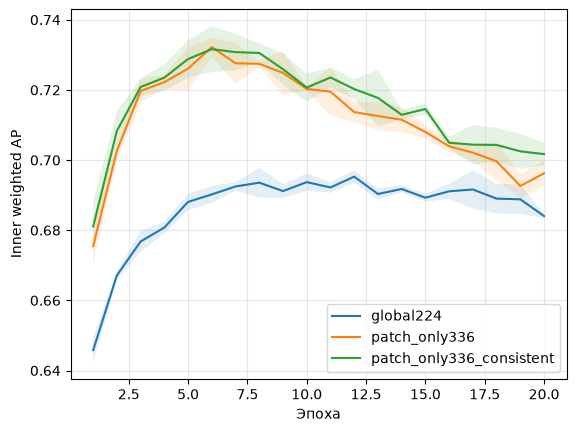

In [39]:
SCREEN_RESULTS=inner_summary(CTX,SCREEN_RUNS)
display(SCREEN_RESULTS[['name','epoch','weighted_ap','f1_final','crossfit_f1_final','crossfit_quality_f1','crossfit_good_rejected','seconds']])
repeat_names=list(dict.fromkeys(['global224',*SCREEN_RESULTS.head(REPEAT_TOP).name.tolist()]))
REPEAT_RUNS=[p for p in SCREEN_RUNS if json.loads((Path(p)/'config.json').read_text())['config']['name'] in repeat_names]
for seed in REPEAT_SEEDS:
    REPEAT_RUNS += run_suite(CTX,REGISTRY,repeat_names,seed)
MEAN_CHOICES,REPEAT_HISTORY=mean_curve_choice(REPEAT_RUNS)
display(MEAN_CHOICES)
for name,h in REPEAT_HISTORY.groupby('name'):
    curve=h.groupby('epoch').weighted_ap.agg(['mean','std'])
    plt.plot(curve.index,curve['mean'],label=name)
    plt.fill_between(curve.index,curve['mean']-curve['std'].fillna(0),curve['mean']+curve['std'].fillna(0),alpha=.12)
plt.ylabel('Inner weighted AP');plt.xlabel('Эпоха');plt.legend();plt.grid(alpha=.3);plt.show()
MEAN_CHOICES.to_csv(CTX.out/'seed_mean_choices.csv',index=False)

## 15. Фиксация финалиста и refit
Сначала фиксируем конфигурацию и число эпох по средним inner-кривым, затем обучаем на full_train. Во время refit нет выбора по outer check. Все обучающие ID, config и hashes доступны в config/checkpoint.

Исторический trial 11 — внешний контроль, а не автоматически переобучаемый кандидат. Если новая модель не выигрывает, её не переносим в основной ноутбук.

In [40]:
selected=MEAN_CHOICES.iloc[0]
FINAL_CONFIG=REGISTRY[selected['name']]
FINAL_EPOCHS=int(selected['epoch'])
save_json(CTX.out/'frozen_selection.json',{'config':asdict(FINAL_CONFIG),'epochs':FINAL_EPOCHS,'seed':42,'criterion':'mean_inner_weighted_ap','protocol':CTX.protocol_hash})
print(f'''Зафиксирован финалист: {FINAL_CONFIG.name}
Эпох: {FINAL_EPOCHS}
''')
FINAL_RUN=run_experiment(CTX,FINAL_CONFIG,seed=42,full=True,fixed_epochs=FINAL_EPOCHS)

Зафиксирован финалист: patch_only336
Эпох: 6



## 16. Calibration и единственный финальный аудит check
Пороги подбираются по f1_final только на calibration. Показываем оба F1, AP, пропущенные плохие и отклонённые хорошие. Пороговая чувствительность оценивается на calibration, не выбирает пороги по check.

Парный bootstrap учитывает группы дубликатов, но не исправляет оптимизм прошлых экспериментов на этой же check. Значительное улучшение должно повториться по seed/разбиениям и затем подтвердиться конкурсом. Автоматической отправки нет.

In [41]:
OUTER_REPORT=evaluate_outer(CTX,FINAL_RUN)
display(OUTER_REPORT)
FINAL_COMPARISON=compare_outer_baseline(CTX,FINAL_RUN)

,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap
split,,,,,,
calibration,0.740260,0.693082,14.33342,58,62,0.740822
check,0.637744,0.663190,13.00934,82,85,0.720505


,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap
historical_trial11,0.572034,0.621235,11.932692,94.0,108.0,0.679660
candidate,0.637744,0.663190,13.009340,82.0,85.0,0.720505


Парный групповой bootstrap разницы F1 final, 95% интервал: [0.49869875 1.64734191]
Это условная оценка для фиксированных моделей и порогов; она не учитывает предшествующий выбор архитектур.


,factor,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap
0,0.8,0.689157,0.680115,13.692721,86,43,0.740822
1,0.9,0.701357,0.689083,13.904404,74,58,0.740822
2,1.0,0.740260,0.693082,14.333420,58,62,0.740822
3,1.1,0.703030,0.680997,13.840272,55,92,0.740822
4,1.2,0.694818,0.678516,13.733335,48,111,0.740822


## 17. Интерпретируемость: ошибки и правильные ответы
Выбираем несколько случаев по фиксированным предсказаниям: ошибочно отклонённый хороший, пропущенный плохой, правильно отклонённый плохой. Показываем ракурсы и изменение logit при замене вида; для patch-модели — attention и gradient×token.

При `PIXEL_OCCLUSION=True` отдельно пересчитываем encoder после маскирования 4×4 областей каждого вида. Это затратнее, но проверяет другое объяснение. Attention и occlusion не являются доказательствами физической причины дефекта. Средний embedding других видов и mean-color область могут быть вне обучающего распределения.

Для устойчивости можно вызвать `explain_case` на одном item/defect для checkpoint разных seed из REPEAT_RUNS; не сравнивайте разные объекты как устойчивость карты.

Кейс: good_rejected



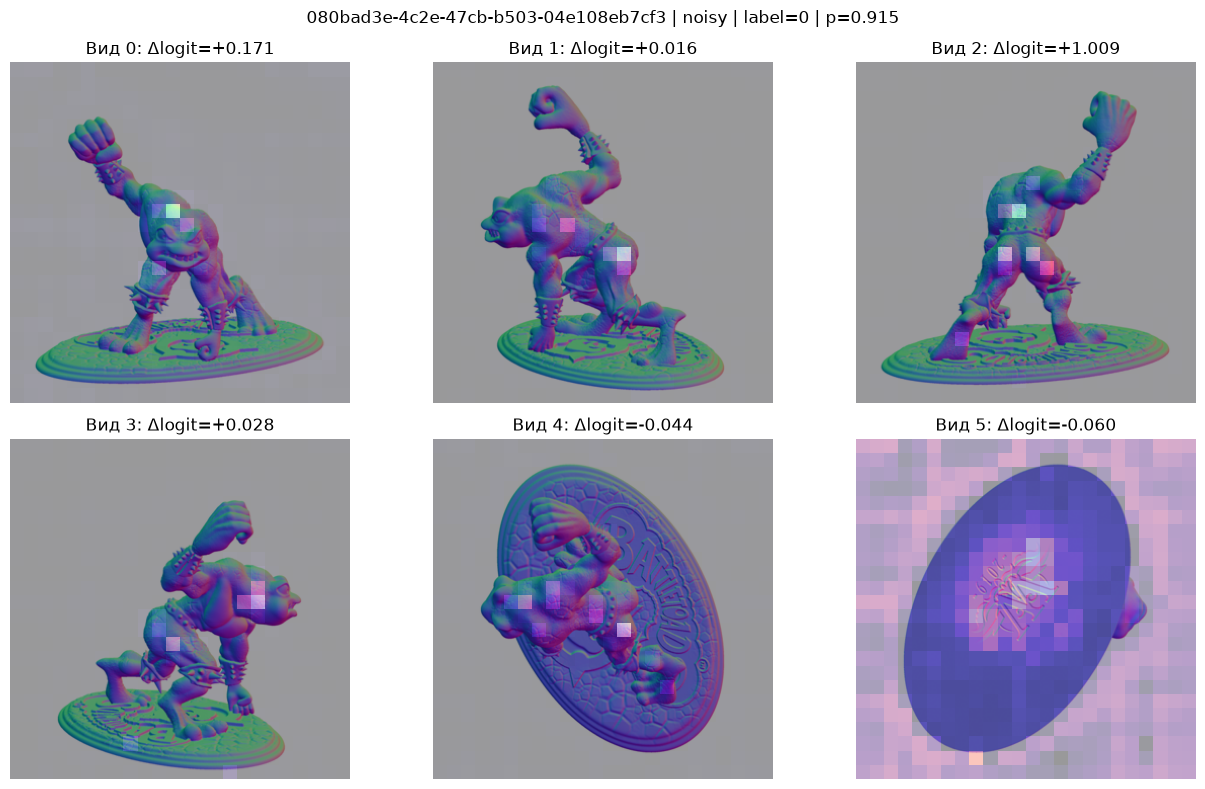

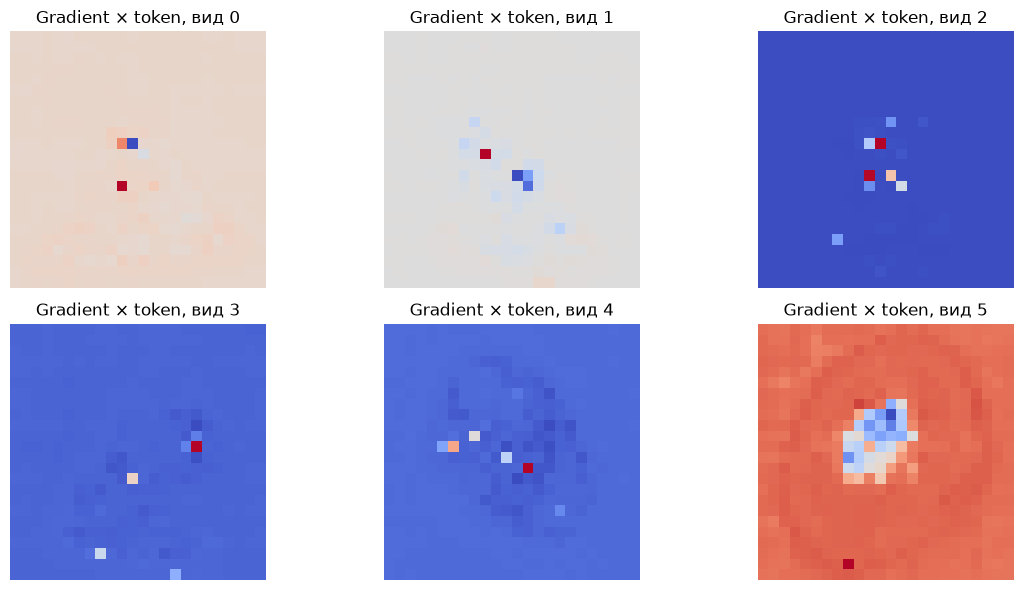

Кейс: bad_accepted



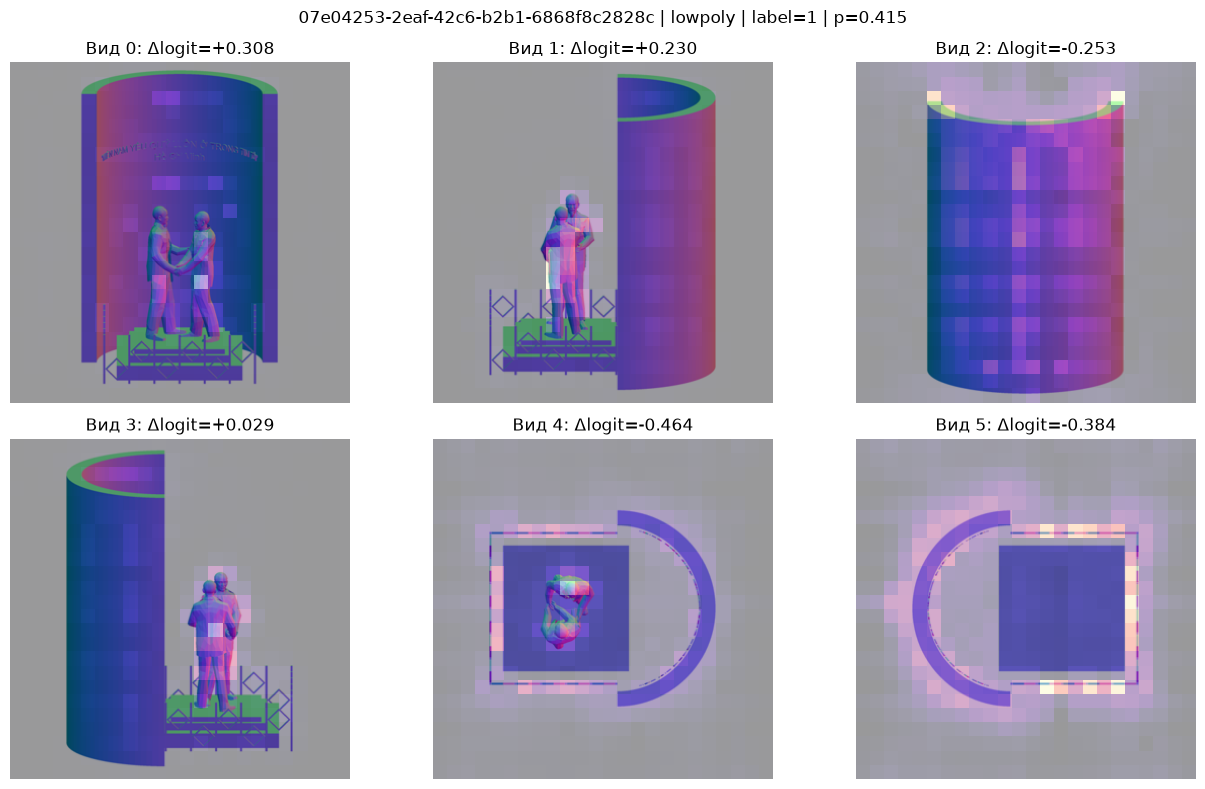

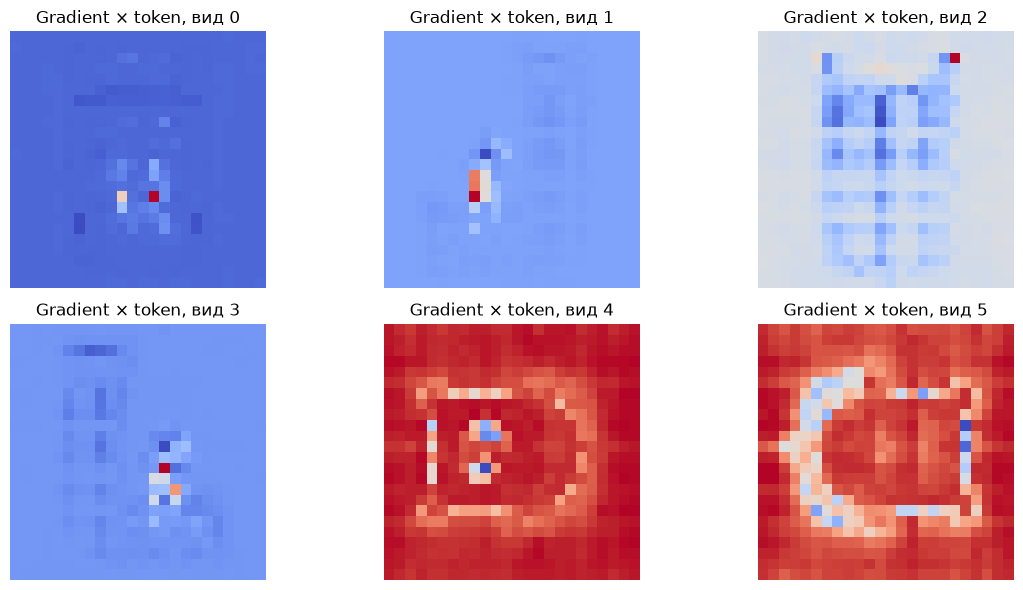

Кейс: bad_rejected



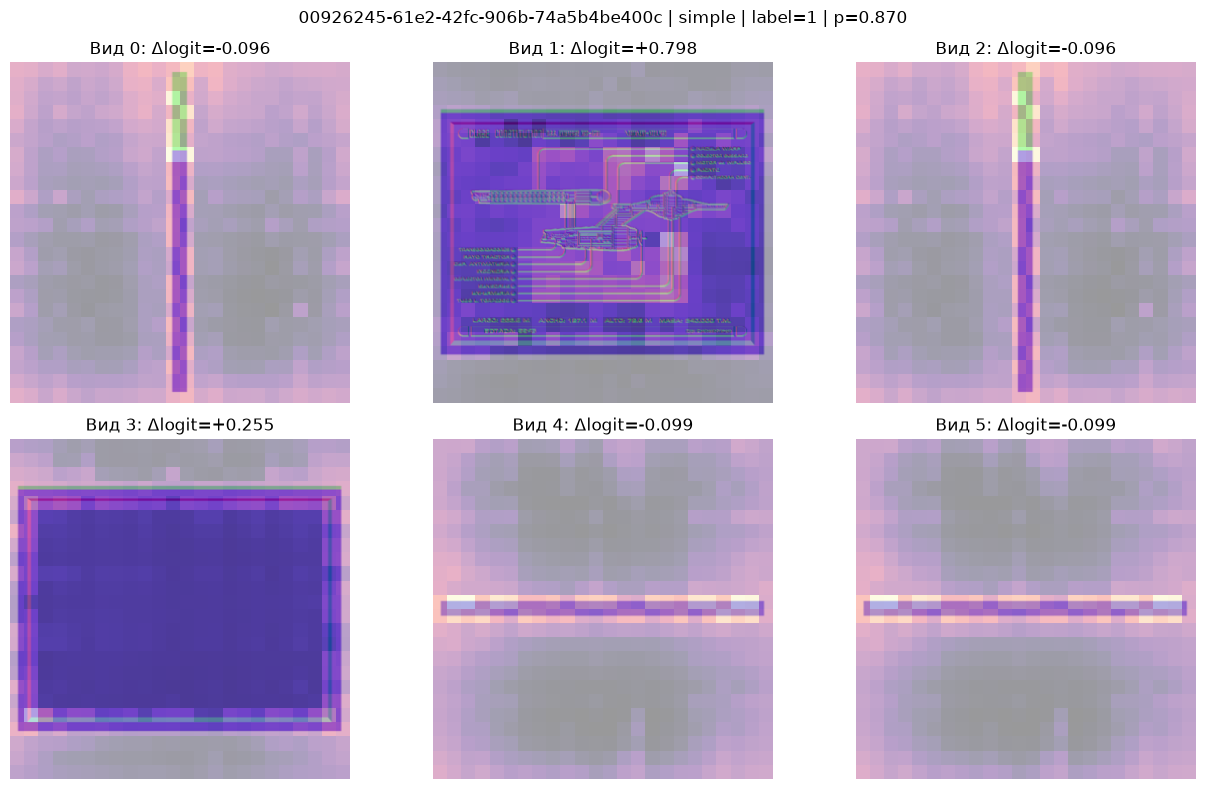

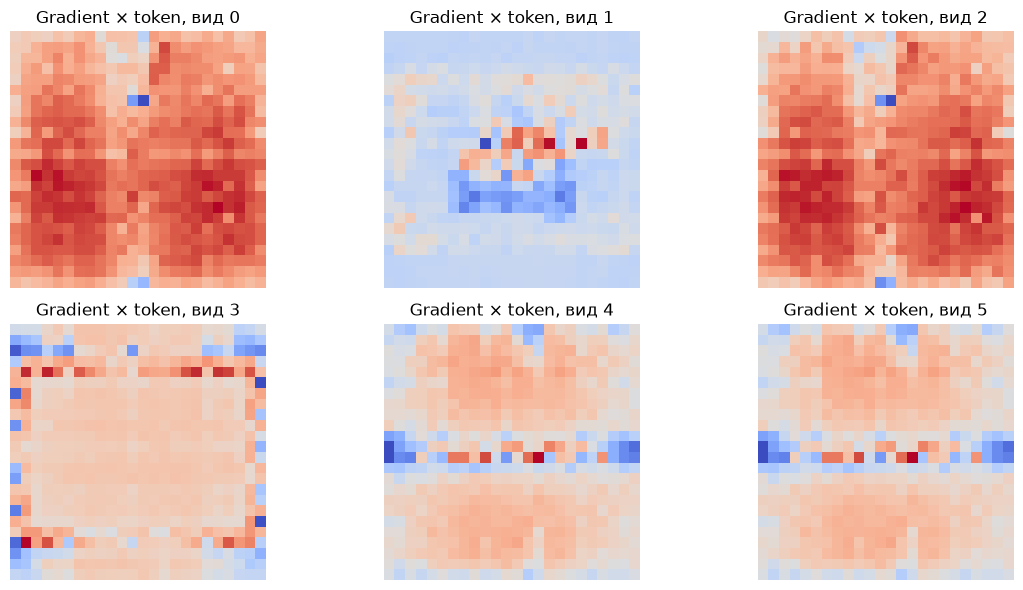

In [42]:
with np.load(Path(FINAL_RUN)/'outer_predictions.npz',allow_pickle=False) as d:
    ids=d['item_ids'].astype(str);y=d['targets'];p=d['probabilities'];t=d['thresholds'];mask=d['check_mask']
pred=p>=t;q=~pred.any(1)
categories={
    'good_rejected':mask&(y[:,10]==1)&~q,
    'bad_accepted':mask&(y[:,10]==0)&q,
    'bad_rejected':mask&(y[:,10]==0)&~q,
}
for category,selection in categories.items():
    candidates=np.flatnonzero(selection)
    if not len(candidates):continue
    i=int(candidates[0])
    if category=='bad_accepted':j=int(np.flatnonzero(y[i,:10])[0])
    else:j=int(np.argmax(p[i]-t))
    print(f'''Кейс: {category}
''')
    explain_case(CTX,FINAL_RUN,ids[i],DEFECTS[j],pixel_occlusion=PIXEL_OCCLUSION)

## 18. Что переносить в основной ноутбук

Переносим только подтверждённую конфигурацию: preprocessing, модель, loss, выбранное число эпох, веса, пороги и объяснения. Отдельно сохраняйте сравнение с историческим trial 11. Test-инференс в лаборатории не запускается, тестовые ответы не используются.

Основные артефакты: `outputs/research_lab/inner_results.csv`, `seed_mean_choices.csv`, `frozen_selection.json`; в FINAL_RUN — `best.pt`, `history.csv`, `thresholds.csv`, `outer_predictions.npz`, `inference.json`, `outer_comparison.csv` и визуализации.

### Источники и границы применимости
- DINOv2: https://github.com/facebookresearch/dinov2 — глобальные и patch-признаки.
- timm: https://github.com/huggingface/pytorch-image-models — используемая реализация ViT и интерполяции позиций.
- Registers: https://arxiv.org/abs/2309.16588 — мотивация осторожной интерпретации patch-карт; модель с registers здесь не подменяет исходный encoder.
- MIL/CLAM: https://pmc.ncbi.nlm.nih.gov/articles/PMC8711640/ — косвенная мотивация attention pooling, не доказательство для mesh defects.
- MVT: https://github.com/shanshuo/MVT — исследовательская мотивация multi-view, не воспроизведение полного метода.
- LoRA: https://arxiv.org/abs/2106.09685 и https://huggingface.co/docs/peft/package_reference/lora — низкоранговая адаптация; здесь компактная реализация PyTorch без PEFT-зависимости.
- ASL: https://github.com/Alibaba-MIIL/ASL — асимметричная multilabel loss.
- Grad-CAM: https://github.com/jacobgil/pytorch-grad-cam — альтернативный метод для будущего сравнения; здесь используются gradient×token и occlusion, а не заявляется реализация Grad-CAM.

Полное OOF-обучение нескольких backbone и mesh/point-архитектуры не входят в первый скрининг. Crossfit порогов здесь не называется OOF-предсказаниями модели. Причинную локализацию без региональной разметки не утверждаем.

# Продолжение: сабмит победителя и следующие эксперименты

Предыдущие выполненные ячейки и результаты сохранены. Новые ячейки ещё не запускались.

План: (1) точный сабмит текущего `patch_only336`, (2) равновесный ансамбль трёх seed, (3) patch336 + fine-tuning последних 1–2 блоков, (4) небольшой поиск LR/dropout/hidden и разбор `open`/`simple`.

**Запуск:** можно начинать прямо с этого раздела после перезапуска ядра: первая ячейка загрузит только определения функций из предыдущих ячеек, без их обучающих вызовов. Используйте то же окружение `.venv`. В текущем ядре также можно продолжать отсюда.

Обучение «на полном train» здесь означает прежние **5970 объектов**, без calibration/check. Эпохи и конфигурации выбираются только по inner weighted AP; пороги — только по calibration F1 final. Check служит отчётом, код не выбирает победителя по ней. Тестовые метки нигде не создаются.

Файлы сабмитов создаются локально. Автоматической отправки на конкурс нет. Первую отправку выполняйте до интерпретации последующих экспериментов; результат платформы не участвует в поиске параметров.

In [43]:
import json, os, sys
from pathlib import Path
from IPython.display import display
NEXT_ROOT = next((p for p in [Path.cwd(), Path('/content/Sber_AI_Major_Task'), Path('/content/drive/MyDrive/Sber_AI_Major_Task')]
                  if (p/'mesh_quality_research.ipynb').exists() and (p/'train.csv').exists()), None)
if NEXT_ROOT is None:
    raise FileNotFoundError('Откройте этот notebook из папки проекта с данными и checkpoints.')
# Reload definitions only. Never execute the old training/evaluation cells.
with open(NEXT_ROOT/'mesh_quality_research.ipynb', encoding='utf-8') as file:
    previous_notebook = json.load(file)
for cell in previous_notebook['cells']:
    if cell['cell_type']=='code' and 'lab_definitions' in cell.get('metadata',{}).get('tags',[]):
        exec(compile(''.join(cell['source']), '<previous lab definitions>', 'exec'), globals())
NEXT_CTX = Context(NEXT_ROOT)
torch.set_num_threads(min(8, os.cpu_count() or 1))
NEXT_DIR = NEXT_CTX.out/'next_steps'
NEXT_DIR.mkdir(parents=True, exist_ok=True)
NEXT_WINNER_RUN = NEXT_CTX.out/'runs/patch_only336_s42_b42583d69e36'
assert (NEXT_WINNER_RUN/'outer_predictions.npz').exists(), 'Сначала нужен завершённый исходный финалист.'
with open(NEXT_WINNER_RUN/'config.json') as file:
    winner_info = json.load(file)
with open(NEXT_WINNER_RUN/'inference.json') as file:
    winner_inference = json.load(file)
NEXT_BASE_CONFIG = Experiment(**winner_info['config'])
NEXT_BASE_EPOCHS = int(winner_info['epochs'])
assert winner_info['full'] and winner_info['seed']==42 and winner_info['protocol']==NEXT_CTX.protocol_hash
assert NEXT_BASE_CONFIG.head=='patch_only' and NEXT_BASE_CONFIG.resolution==336 and NEXT_BASE_CONFIG.adaptation=='frozen'
assert NEXT_BASE_EPOCHS==6 and winner_inference['source_sha256']==NEXT_CTX.source_hash
assert winner_inference['defect_columns']==DEFECTS
NEXT_FIXED_THRESHOLDS = np.asarray(winner_inference['thresholds'], dtype=np.float64)
with np.load(NEXT_WINNER_RUN/'outer_predictions.npz', allow_pickle=False) as saved:
    np.testing.assert_array_equal(saved['thresholds'], NEXT_FIXED_THRESHOLDS)
print(f'''Продолжение готово к запуску.
Устройство: {NEXT_CTX.device}
Исходный финалист: {NEXT_WINNER_RUN.name}
Эпох: {NEXT_BASE_EPOCHS}
Артефакты новых этапов: {NEXT_DIR}
''')

Продолжение готово к запуску.
Устройство: mps
Исходный финалист: patch_only336_s42_b42583d69e36
Эпох: 6
Артефакты новых этапов: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/research_lab/next_steps



## 19. Настройки продолжения

Все три обучающих этапа включены. Текущий и ансамблевый сабмиты создаются автоматически при выполнении соответствующих ячеек. Экспорт новых fine-tuned/HPO кандидатов включается отдельно, чтобы не извлекать тестовые признаки для каждого исследовательского варианта.

**Ресурсы:** дополнительный тестовый patch336-кэш — примерно 1.7 GiB. Fine-tuning работает с исходными PNG, кэш patch-токенов для изменяемого encoder не используется. 336px заметно дороже прежнего fine-tuning 224; microbatch=1 объект (6 видов), effective batch=16. Первый этап fine-tuning: три конфигурации по 8 эпох; затем повторение лучшей и контроля по seed. Поиск головы: 12 комбинаций по 20 эпох плюс повторы финалистов.

При нехватке памяти уменьшение effective batch само по себе не уменьшит один forward: потребуется другой resolution или отдельная реализация обработки видов. Разрешение внутри сравнения скрыто не меняем.

In [44]:
# Режим дедлайна: тяжёлые этапы отключены.
NEXT_SEEDS = (42, 17, 123)
NEXT_EXPORT_CURRENT = True
NEXT_RUN_ENSEMBLE = False
NEXT_RUN_FINETUNE = False
NEXT_RUN_HEAD_SEARCH = False
NEXT_EXPORT_NEW_CANDIDATES = False
NEXT_SHOW_ERRORS = True
NEXT_EVALUATIONS = []
NEXT_SUBMISSIONS = {}


## 20. Служебные функции продолжения

Кэш вероятностей привязан к хешу checkpoint, источнику DINOv2, ID, конфигурации, устройству и версиям библиотек. Тестовый token-cache отделён от обучающего. В ensemble усредняются **вероятности**, не logits и не бинарные ответы; веса трёх seed фиксированы по 1/3.

Для fine-tuning и поиска головы существующий frozen patch336 участвует как контроль. После inner-выбора фиксируются конфигурация и число эпох, затем выполняется refit. Внешние метрики не передаются функциям выбора.

In [45]:
# Continuation helpers: keep all prior definitions and executed cells intact.
from IPython.display import display

class NextTestContext(Context):
    """Separate test cache; never provide invented test labels to evaluation."""
    def __init__(self, ctx):
        self.__dict__ = ctx.__dict__.copy()
        self.all_ids = pd.read_csv(ctx.root/'test.csv', dtype={'item_id': str}).item_id.tolist()
        assert len(self.all_ids) == len(set(self.all_ids)) and self.all_ids
        self.rows = {item: i for i, item in enumerate(self.all_ids)}
        self.out = ctx.out/'next_steps'/'test_cache'
        self.out.mkdir(parents=True, exist_ok=True)
        self._stores = {}
    def images(self, item, resolution):
        with Image.open(self.root/'test'/f'{item}.png') as image:
            image = image.convert('RGB')
        w, h = image.size
        assert w % 3 == 0 and h % 2 == 0 and w//3 == h//2
        transform = self.transform(resolution)
        return torch.stack([
            transform(image.crop((c*w//3, r*h//2, (c+1)*w//3, (r+1)*h//2)))
            for r in range(2) for c in range(3)
        ])
    def labels(self, ids):
        raise RuntimeError('Test labels are unavailable; use inference only.')

class NextInferenceDataset(Dataset):
    def __init__(self, ctx, ids, cfg, test=False):
        self.ctx, self.ids, self.cfg, self.test = ctx, list(ids), cfg, test
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        item, cfg = self.ids[i], self.cfg
        if cfg.adaptation != 'frozen':
            return {'images': self.ctx.images(item, cfg.resolution)}
        if not self.test:
            b = LabDataset(self.ctx, [item], cfg)[0]
            return {k: v for k, v in b.items() if k not in ('targets', 'item_id')}
        store = token_store(self.ctx, cfg.resolution)
        row = self.ctx.rows[item]
        assert store.ready[row]
        b = {'global': torch.from_numpy(np.array(getattr(store, 'global')[row], dtype=np.float32))}
        if needs_patch(cfg):
            b['patch'] = torch.from_numpy(np.array(store.patch[row], dtype=np.float32))
        return b

def next_run_info(run):
    run = Path(run)
    config = json.loads((run/'config.json').read_text())
    assert (run/'complete.json').exists() and (run/'best.pt').exists(), run
    return config

def next_validate_run(ctx, run, full=True):
    info = next_run_info(run)
    assert info['full'] == full and info['protocol'] == ctx.protocol_hash
    return info

def next_validate_probabilities(p, count):
    p = np.asarray(p, dtype=np.float32)
    assert p.shape == (count, len(DEFECTS))
    assert np.isfinite(p).all() and ((p >= 0) & (p <= 1)).all()
    return p

@torch.inference_mode()
def next_probabilities(ctx, run, test=False):
    next_validate_run(ctx, run)
    run = Path(run)
    cfg = Experiment(**next_run_info(run)['config'])
    assert cfg.head != 'render', 'This extension handles image and patch models.'
    data_ctx = NextTestContext(ctx) if test else ctx
    ids = data_ctx.all_ids if test else ctx.ids['valid']
    key = {
        'schema': 1, 'checkpoint_sha256': digest(run/'best.pt'),
        'source_sha256': ctx.source_hash, 'ids': ids,
        'split': 'test' if test else 'valid', 'config': asdict(cfg),
        'torch': str(torch.__version__), 'timm': timm.__version__, 'device': str(ctx.device),
    }
    directory = ctx.out/'next_steps'/'predictions'
    directory.mkdir(parents=True, exist_ok=True)
    target = directory/f'{canonical_hash(key)}.npz'
    if target.exists():
        with np.load(target, allow_pickle=False) as cached:
            assert cached['item_ids'].astype(str).tolist() == ids
            assert json.loads(str(cached['metadata'].item())) == key
            return np.asarray(ids), next_validate_probabilities(cached['probabilities'], len(ids))
    if cfg.adaptation == 'frozen':
        if test: token_store(data_ctx, cfg.resolution).ensure(ids)
        else: prepare(data_ctx, ids, cfg)
    model, _, _ = load_run(ctx, run)
    loader = DataLoader(NextInferenceDataset(data_ctx, ids, cfg, test), batch_size=cfg.microbatch, shuffle=False, num_workers=0)
    outputs = []
    for batch in tqdm(loader, desc=f"{cfg.name}: {key['split']}"):
        outputs.append(model(move_batch(batch, ctx.device))[0].sigmoid().cpu().numpy())
    p = next_validate_probabilities(np.concatenate(outputs), len(ids))
    with open(target.with_suffix('.tmp'), 'wb') as file:
        np.savez_compressed(file, item_ids=np.asarray(ids), probabilities=p, metadata=json.dumps(key, sort_keys=True))
    target.with_suffix('.tmp').replace(target)
    del model, loader, data_ctx
    release()
    return np.asarray(ids), p

def next_average(ctx, runs, test=False):
    assert runs and len(set(map(str, runs))) == len(runs)
    reference, total = None, None
    for run in runs:
        ids, p = next_probabilities(ctx, run, test)
        if reference is None:
            reference, total = ids, p.astype(np.float64)
        else:
            np.testing.assert_array_equal(reference, ids)
            total += p
    return reference, next_validate_probabilities(total/len(runs), len(reference))

def next_export(ctx, runs, thresholds, label):
    """Export only. Never upload or tune thresholds using test predictions."""
    thresholds = np.asarray(thresholds, dtype=np.float64)
    assert thresholds.shape == (10,) and np.isfinite(thresholds).all()
    assert ((thresholds >= 0) & (thresholds <= 1)).all()
    ids, p = next_average(ctx, runs, test=True)
    expected = pd.read_csv(ctx.root/'test.csv', dtype={'item_id': str}).item_id.tolist()
    assert ids.tolist() == expected
    pred = (p >= thresholds).astype(np.int64)
    submission = pd.DataFrame(pred, columns=DEFECTS)
    submission.insert(0, 'item_id', ids)
    submission['quality'] = (~pred.any(axis=1)).astype(np.int64)
    assert submission.columns.tolist() == ['item_id', *TARGETS]
    assert not submission.isna().any().any() and submission.item_id.is_unique
    recipe = {'label': label, 'runs': [str(Path(r).relative_to(ctx.root)) for r in runs],
              'checkpoint_sha256': [digest(Path(r)/'best.pt') for r in runs],
              'source_sha256': ctx.source_hash, 'thresholds': thresholds.tolist(),
              'defect_columns': DEFECTS, 'quality_rule': 'no_predicted_defects',
              'blend': 'equal_mean_probabilities', 'test_ids_sha256': canonical_hash(expected)}
    folder = ctx.out/'next_steps'/'submissions'; folder.mkdir(parents=True, exist_ok=True)
    path = folder/f'submission_{label}_{canonical_hash(recipe)[:10]}.csv'
    submission.to_csv(path.with_suffix('.tmp'), index=False)
    path.with_suffix('.tmp').replace(path)
    restored = pd.read_csv(path, dtype={'item_id': str})
    pd.testing.assert_frame_equal(restored, submission)
    recipe['csv_sha256'] = digest(path)
    save_json(path.with_suffix('.json'), recipe)
    print(f'''Сабмит: {path}
Объектов: {len(submission)}
Хороших: {int(submission.quality.sum())}
Пороги и хеши весов сохранены рядом. Отправка на платформу не выполняется.
''')
    return path

def next_evaluate(ctx, runs, label):
    ids, p = next_average(ctx, runs, test=False)
    y = ctx.labels(ids)
    cal = np.isin(ids, ctx.ids['calibration']); check = np.isin(ids, ctx.ids['check'])
    assert not (cal & check).any() and (cal | check).all()
    thresholds, history = tune_thresholds(y[cal], p[cal])
    recipe = {'schema': 1, 'label': label, 'runs': [str(Path(r).relative_to(ctx.root)) for r in runs],
              'checkpoint_sha256': [digest(Path(r)/'best.pt') for r in runs],
              'protocol': ctx.protocol_hash, 'threshold_fit': 'calibration_f1_final',
              'blend': 'equal_mean_probabilities'}
    directory = ctx.out/'next_steps'/'evaluations'/f'{label}_{canonical_hash(recipe)[:10]}'
    directory.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(directory/'predictions.npz', item_ids=ids, targets=y, probabilities=p,
                        thresholds=thresholds, calibration_mask=cal, check_mask=check)
    pd.DataFrame({'defect': DEFECTS, 'threshold': thresholds}).to_csv(directory/'thresholds.csv', index=False)
    history.to_csv(directory/'threshold_history.csv', index=False)
    save_json(directory/'recipe.json', recipe)
    report = pd.DataFrame([{'split': name, **scores(y[mask], p[mask], thresholds)}
                           for name, mask in [('calibration', cal), ('check', check)]]).set_index('split')
    report.to_csv(directory/'metrics.csv'); display(report)
    return {'label': label, 'runs': list(runs), 'thresholds': thresholds, 'directory': directory, 'report': report}

def next_existing_inner(ctx, cfg, seed):
    matches = []
    for path in (ctx.out/'runs').glob('*'):
        if not (path/'complete.json').exists(): continue
        info = next_run_info(path)
        if not info['full'] and info['protocol'] == ctx.protocol_hash and info['seed'] == seed and info['config'] == asdict(cfg):
            matches.append(path)
    assert len(matches) <= 1, f'Ambiguous previous run: {cfg.name}, seed={seed}'
    return matches[0] if matches else run_experiment(ctx, cfg, seed=seed)

def next_full(ctx, cfg, seed, epochs, winner_run):
    info = next_run_info(winner_run)
    if info['config'] == asdict(cfg) and info['seed'] == seed and info['epochs'] == epochs:
        next_validate_run(ctx, winner_run)
        return Path(winner_run)
    return run_experiment(ctx, cfg, seed=seed, full=True, fixed_epochs=epochs)

def next_select_refit(ctx, configs, first_runs, base_cfg, winner_run, stage, seeds=(42,17,123), top=2):
    """Select only on inner data. Include the predeclared existing winner as a control."""
    assert len(first_runs) == len(configs)
    rows = []
    for cfg, run in zip(configs, first_runs):
        info = next_validate_run(ctx, run, full=False)
        assert info['seed'] == seeds[0] and info['config'] == asdict(cfg)
        h = pd.read_csv(Path(run)/'history.csv')
        rows.append({'name': cfg.name, 'weighted_ap': float(h.weighted_ap.max()), 'run': str(run)})
    ranking = pd.DataFrame(rows).sort_values(['weighted_ap','name'], ascending=[False, True])
    directory = ctx.out/'next_steps'/stage; directory.mkdir(parents=True, exist_ok=True)
    ranking.to_csv(directory/'screen.csv', index=False); display(ranking)
    lookup = {c.name: c for c in configs}
    selected_names = ranking.head(top).name.tolist()
    repeat_cfgs = [lookup[name] for name in selected_names]
    if base_cfg.name not in selected_names: repeat_cfgs.append(base_cfg)
    repeated = []
    for cfg in repeat_cfgs:
        for seed in seeds:
            repeated.append(next_existing_inner(ctx, cfg, seed))
    choices, history = mean_curve_choice(repeated)
    choices.to_csv(directory/'mean_choices.csv', index=False)
    history.to_csv(directory/'repeat_history.csv', index=False); display(choices)
    chosen = choices.iloc[0]
    all_cfgs = {c.name: c for c in repeat_cfgs}
    cfg = all_cfgs[chosen['name']]; epochs = int(chosen['epoch'])
    # Freeze before any new outer predictions are requested.
    save_json(directory/'selection.json', {'config': asdict(cfg), 'epochs': epochs, 'seeds': list(seeds),
              'criterion': 'mean_inner_weighted_ap', 'protocol': ctx.protocol_hash})
    full_runs = [next_full(ctx, cfg, seed, epochs, winner_run) for seed in seeds]
    return full_runs, cfg, epochs

def next_error_report(ctx, evaluations, winner_run):
    # Diagnostic only: no fitting or automatic threshold/architecture changes on check.
    with np.load(Path(winner_run)/'outer_predictions.npz', allow_pickle=False) as d:
        reference_ids = d['item_ids'].astype(str); y = d['targets']; old_p = d['probabilities']
        old_t = d['thresholds']; mask = d['check_mask']
    original = old_p >= old_t
    reports = []
    for result in evaluations:
        with np.load(result['directory']/'predictions.npz', allow_pickle=False) as d:
            ix = pd.Index(d['item_ids'].astype(str)).get_indexer(reference_ids); assert (ix >= 0).all()
            np.testing.assert_array_equal(d['targets'][ix], y)
            p = d['probabilities'][ix]; pred = p >= d['thresholds']
        for defect in ['open', 'simple']:
            j = DEFECTS.index(defect); truth = y[:,j].astype(bool)
            good = y[:,10] == 1
            reports.append({'variant': result['label'], 'defect': defect,
                'f1_before': f1_score(truth[mask], original[mask,j], zero_division=0),
                'f1_after': f1_score(truth[mask], pred[mask,j], zero_division=0),
                'FP_on_good_before': int((mask & good & original[:,j]).sum()),
                'FP_on_good_after': int((mask & good & pred[:,j]).sum()),
                'FN_after': int((mask & truth & ~pred[:,j]).sum())})
            cases = pd.DataFrame({'item_id': reference_ids, 'true_label': truth.astype(int), 'probability': p[:,j],
                       'FP': mask & ~truth & pred[:,j], 'FN': mask & truth & ~pred[:,j]})
            cases[cases.FP | cases.FN].to_csv(result['directory']/f'{defect}_check_errors.csv', index=False)
    table = pd.DataFrame(reports); display(table)
    table.to_csv(ctx.out/'next_steps'/'open_simple_report.csv', index=False)
    return table

def next_show_error_cases(ctx, result, defect, count=2):
    cases = pd.read_csv(result['directory']/f'{defect}_check_errors.csv', dtype={'item_id':str})
    for error in ['FP','FN']:
        chosen = cases[cases[error]].sort_values('probability', ascending=(error=='FN')).head(count)
        for row in chosen.itertuples():
            with Image.open(ctx.root/'train'/f'{row.item_id}.png') as im:
                fig, ax = plt.subplots(figsize=(12,8)); ax.imshow(im); ax.axis('off')
                ax.set_title(f'{defect} | {error} | {row.item_id} | p={row.probability:.3f}')
                plt.show(); plt.close(fig)


## 21. Проверка воспроизведения и сабмит текущего победителя

Здесь загружается **тот же** `best.pt` и **те же** сохранённые 10 порогов. Нового обучения или подбора порогов нет. Перед test-инференсом сравниваем вероятности на validation с сохранёнными. Затем извлекаем patch-токены теста и формируем CSV строго в порядке `test.csv`.

Первое извлечение тестового кэша потребует времени. Повторный запуск использует готовые строки/вероятности. Если проверка воспроизведения падает, её нужно исследовать, а не удалять.

In [46]:
if NEXT_EXPORT_CURRENT:
    reproduced_ids, reproduced_p = next_probabilities(NEXT_CTX, NEXT_WINNER_RUN, test=False)
    with np.load(NEXT_WINNER_RUN/'outer_predictions.npz', allow_pickle=False) as saved:
        order = pd.Index(saved['item_ids'].astype(str)).get_indexer(reproduced_ids)
        assert (order >= 0).all()
        expected_p = saved['probabilities'][order]
    np.testing.assert_allclose(reproduced_p, expected_p, rtol=1e-3, atol=2e-4)
    mismatch = int(((reproduced_p >= NEXT_FIXED_THRESHOLDS) != (expected_p >= NEXT_FIXED_THRESHOLDS)).sum())
    print(f'''Максимальное отличие вероятностей: {np.abs(reproduced_p-expected_p).max():.8f}
Изменившихся бинарных ответов на validation: {mismatch}
''')
    # Same-device reproduction should preserve all binary decisions.
    if mismatch:
        raise RuntimeError('Вероятности близки, но изменились решения у порога. Проверьте среду перед сабмитом.')
    NEXT_SUBMISSIONS['current'] = next_export(NEXT_CTX, [NEXT_WINNER_RUN], NEXT_FIXED_THRESHOLDS, 'patch_only336_seed42')


patch_only336: valid:   0%|          | 0/2994 [00:00<?, ?it/s]

Максимальное отличие вероятностей: 0.00000000
Изменившихся бинарных ответов на validation: 0



Tokens 336:   0%|          | 0/669 [00:00<?, ?it/s]

patch_only336: test:   0%|          | 0/669 [00:00<?, ?it/s]

Сабмит: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/research_lab/next_steps/submissions/submission_patch_only336_seed42_ab7436e71e.csv
Объектов: 669
Хороших: 119
Пороги и хеши весов сохранены рядом. Отправка на платформу не выполняется.



## 22. Ансамбль трёх seed на full_train

Seed 42 уже обучен 6 эпох и переиспользуется. Seed 17 и 123 обучаются с тем же числом эпох и конфигурацией на тех же 5970 объектах. Пороги подбираются для среднего вероятностей заново на calibration, после чего показывается check и создаётся отдельный сабмит.

Это отдельный эксперимент, а не замена файлов первого сабмита.

In [47]:
if NEXT_RUN_ENSEMBLE:
    NEXT_ENSEMBLE_RUNS = [next_full(NEXT_CTX, NEXT_BASE_CONFIG, seed, NEXT_BASE_EPOCHS, NEXT_WINNER_RUN)
                          for seed in NEXT_SEEDS]
    NEXT_ENSEMBLE = next_evaluate(NEXT_CTX, NEXT_ENSEMBLE_RUNS, 'patch336_three_seeds')
    NEXT_EVALUATIONS.append(NEXT_ENSEMBLE)
    NEXT_SUBMISSIONS['ensemble'] = next_export(NEXT_CTX, NEXT_ENSEMBLE_RUNS,
                                               NEXT_ENSEMBLE['thresholds'], 'patch_only336_three_seeds')


patch_only336 | seed 17 | эпоха 1/6
Loss: 0.21685 | weighted AP: nan | F1: nan | 33.9 с
patch_only336 | seed 17 | эпоха 2/6
Loss: 0.17317 | weighted AP: nan | F1: nan | 21.6 с
patch_only336 | seed 17 | эпоха 3/6
Loss: 0.15924 | weighted AP: nan | F1: nan | 18.2 с
patch_only336 | seed 17 | эпоха 4/6
Loss: 0.15073 | weighted AP: nan | F1: nan | 17.8 с
patch_only336 | seed 17 | эпоха 5/6
Loss: 0.14347 | weighted AP: nan | F1: nan | 18.0 с
patch_only336 | seed 17 | эпоха 6/6
Loss: 0.13600 | weighted AP: nan | F1: nan | 18.3 с
patch_only336 | seed 123 | эпоха 1/6
Loss: 0.21745 | weighted AP: nan | F1: nan | 17.5 с
patch_only336 | seed 123 | эпоха 2/6
Loss: 0.17295 | weighted AP: nan | F1: nan | 17.6 с
patch_only336 | seed 123 | эпоха 3/6
Loss: 0.16025 | weighted AP: nan | F1: nan | 17.8 с
patch_only336 | seed 123 | эпоха 4/6
Loss: 0.15152 | weighted AP: nan | F1: nan | 17.9 с
patch_only336 | seed 123 | эпоха 5/6
Loss: 0.14427 | weighted AP: nan | F1: nan | 18.3 с
patch_only336 | seed 123 | 

patch_only336: valid:   0%|          | 0/2994 [00:00<?, ?it/s]

patch_only336: valid:   0%|          | 0/2994 [00:00<?, ?it/s]

,f1_quality,f1_defects_weighted,f1_final,good_rejected,bad_accepted,weighted_ap
split,,,,,,
calibration,0.74739,0.696225,14.436149,50,71,0.746041
check,0.64557,0.676201,13.217709,76,92,0.728463


patch_only336: test:   0%|          | 0/669 [00:00<?, ?it/s]

patch_only336: test:   0%|          | 0/669 [00:00<?, ?it/s]

Сабмит: /Users/savin/Documents/Programming/AI Chellenge/Sber_AI_Major_Task/outputs/research_lab/next_steps/submissions/submission_patch_only336_three_seeds_51b5edf5f6.csv
Объектов: 669
Хороших: 111
Пороги и хеши весов сохранены рядом. Отправка на платформу не выполняется.



## 23. Patch-only 336 + fine-tuning последних блоков

Первое сравнение: frozen / last1 / last2 с одинаковой patch-головой, BCE, head LR=1e-4, восемью эпохами и batch. Backbone LR=1e-5. Головы стартуют с нуля, чтобы исходная full_train голова не внесла информацию об inner_valid.

`OnlineModel` уже поддерживает patch-токены: gradient проходит через attention, токены и выбранные последние блоки DINOv2. Используются исходные PNG. После скрининга лучший из трёх вариантов повторяется на дополнительных seed и сравнивается с прежним победителем по средним inner-кривым. Если новый вариант не выигрывает, контроль может остаться выбранным.

На внешнем этапе оценивается равновесный ансамбль трёх refit-моделей выбранной конфигурации. Результат сохраняется отдельно от ансамбля предыдущего раздела.

In [ ]:
if NEXT_RUN_FINETUNE:
    NEXT_FT_CONFIGS = [replace(NEXT_BASE_CONFIG, name='next_patch336_'+adaptation,
                               adaptation=adaptation, epochs=8, lr=1e-4, backbone_lr=1e-5,
                               microbatch=1, effective_batch=16)
                       for adaptation in ['frozen', 'last1', 'last2']]
    NEXT_FT_SCREEN = [run_experiment(NEXT_CTX, cfg, seed=NEXT_SEEDS[0]) for cfg in NEXT_FT_CONFIGS]
    NEXT_FT_RUNS, NEXT_FT_CONFIG, NEXT_FT_EPOCHS = next_select_refit(
        NEXT_CTX, NEXT_FT_CONFIGS, NEXT_FT_SCREEN, NEXT_BASE_CONFIG, NEXT_WINNER_RUN,
        stage='patch_finetune', seeds=NEXT_SEEDS, top=1)
    NEXT_FT_RESULT = next_evaluate(NEXT_CTX, NEXT_FT_RUNS, 'patch336_finetune_selected')
    NEXT_EVALUATIONS.append(NEXT_FT_RESULT)
    if NEXT_EXPORT_NEW_CANDIDATES:
        NEXT_SUBMISSIONS['finetune'] = next_export(NEXT_CTX, NEXT_FT_RUNS,
            NEXT_FT_RESULT['thresholds'], 'patch336_finetune_selected')


next_patch336_frozen | seed 42 | эпоха 1/8
Loss: 0.27590 | weighted AP: 0.59534 | F1: 7.7642 | 32.4 с
next_patch336_frozen | seed 42 | эпоха 2/8
Loss: 0.20476 | weighted AP: 0.66270 | F1: 10.2313 | 18.5 с
next_patch336_frozen | seed 42 | эпоха 3/8
Loss: 0.18593 | weighted AP: 0.68622 | F1: 10.6849 | 18.4 с
next_patch336_frozen | seed 42 | эпоха 4/8
Loss: 0.17674 | weighted AP: 0.69587 | F1: 11.1352 | 19.1 с
next_patch336_frozen | seed 42 | эпоха 5/8
Loss: 0.17037 | weighted AP: 0.70370 | F1: 11.4223 | 16.6 с
next_patch336_frozen | seed 42 | эпоха 6/8
Loss: 0.16488 | weighted AP: 0.70914 | F1: 11.1626 | 16.7 с
next_patch336_frozen | seed 42 | эпоха 7/8
Loss: 0.16028 | weighted AP: 0.71461 | F1: 11.6368 | 16.6 с
next_patch336_frozen | seed 42 | эпоха 8/8
Loss: 0.15625 | weighted AP: 0.72144 | F1: 11.8035 | 17.8 с
next_patch336_last1 | seed 42 | эпоха 1/8
Loss: 0.26586 | weighted AP: 0.63320 | F1: 8.9258 | 393.8 с
next_patch336_last1 | seed 42 | эпоха 2/8
Loss: 0.19471 | weighted AP: 0.69

,name,weighted_ap,run
2,next_patch336_last2,0.744268,/Users/savin/Documents/Programming/AI Chelleng...
1,next_patch336_last1,0.737755,/Users/savin/Documents/Programming/AI Chelleng...
0,next_patch336_frozen,0.721442,/Users/savin/Documents/Programming/AI Chelleng...


next_patch336_last2 | seed 17 | эпоха 1/8
Loss: 0.25854 | weighted AP: 0.66403 | F1: 9.7026 | 433.8 с
next_patch336_last2 | seed 17 | эпоха 2/8
Loss: 0.18787 | weighted AP: 0.71610 | F1: 11.5083 | 440.2 с
next_patch336_last2 | seed 17 | эпоха 3/8
Loss: 0.17091 | weighted AP: 0.72996 | F1: 11.5370 | 436.5 с
next_patch336_last2 | seed 17 | эпоха 4/8
Loss: 0.15819 | weighted AP: 0.73361 | F1: 11.9797 | 441.2 с
next_patch336_last2 | seed 17 | эпоха 5/8
Loss: 0.14705 | weighted AP: 0.74544 | F1: 12.4726 | 435.3 с
next_patch336_last2 | seed 17 | эпоха 6/8
Loss: 0.13756 | weighted AP: 0.74651 | F1: 12.2872 | 441.1 с
next_patch336_last2 | seed 17 | эпоха 7/8
Loss: 0.12606 | weighted AP: 0.74439 | F1: 13.0073 | 436.6 с
next_patch336_last2 | seed 17 | эпоха 8/8
Loss: 0.11319 | weighted AP: 0.74127 | F1: 12.5527 | 439.0 с
next_patch336_last2 | seed 123 | эпоха 1/8
Loss: 0.25522 | weighted AP: 0.66012 | F1: 9.1233 | 441.3 с
next_patch336_last2 | seed 123 | эпоха 2/8
Loss: 0.18597 | weighted AP: 0.

,name,epoch,weighted_ap
5,next_patch336_last2,6,0.744935
13,patch_only336,6,0.732204


## 24. Небольшой поиск параметров frozen patch-головы

Для интерпретируемого сравнения ищем параметры **исходного frozen patch-only336**, независимо от результата fine-tuning. Сетка: LR {2e-4, 5e-4, 1e-3} × dropout {0.2, 0.45} × hidden {128, 256} = 12 запусков. Weight decay фиксирован. Это прозрачный воспроизводимый grid search; дополнительная зависимость Optuna здесь не нужна.

Первичный выбор — weighted AP на inner_valid. Две лучшие конфигурации повторяются на трёх seed вместе с исходным контролем; средняя кривая задаёт эпоху refit. Test и check не используются в поиске. После большого числа экспериментов inner-оценка оптимистична: финальный отчёт не трактуем как независимое доказательство общего прироста.

In [ ]:
if NEXT_RUN_HEAD_SEARCH:
    from itertools import product
    NEXT_SEARCH_CONFIGS = [replace(NEXT_BASE_CONFIG, name=f'next_patch336_grid_{i:02d}',
                                   lr=lr, dropout=dropout, hidden=hidden, epochs=20)
                           for i, (lr, dropout, hidden) in enumerate(product(
                               [2e-4, 5e-4, 1e-3], [0.2, 0.45], [128, 256]))]
    display(pd.DataFrame([{'name': c.name, 'lr': c.lr, 'dropout': c.dropout, 'hidden': c.hidden}
                          for c in NEXT_SEARCH_CONFIGS]))
    NEXT_SEARCH_SCREEN = [run_experiment(NEXT_CTX, cfg, seed=NEXT_SEEDS[0]) for cfg in NEXT_SEARCH_CONFIGS]
    NEXT_SEARCH_RUNS, NEXT_SEARCH_CONFIG, NEXT_SEARCH_EPOCHS = next_select_refit(
        NEXT_CTX, NEXT_SEARCH_CONFIGS, NEXT_SEARCH_SCREEN, NEXT_BASE_CONFIG, NEXT_WINNER_RUN,
        stage='patch_head_search', seeds=NEXT_SEEDS, top=2)
    NEXT_SEARCH_RESULT = next_evaluate(NEXT_CTX, NEXT_SEARCH_RUNS, 'patch336_head_search_selected')
    NEXT_EVALUATIONS.append(NEXT_SEARCH_RESULT)
    if NEXT_EXPORT_NEW_CANDIDATES:
        NEXT_SUBMISSIONS['head_search'] = next_export(NEXT_CTX, NEXT_SEARCH_RUNS,
            NEXT_SEARCH_RESULT['thresholds'], 'patch336_head_search_selected')


## 25. Сводка и ошибки open/simple

Сравнение использует одни и те же объекты check. Здесь нет автоматического выбора «лучшей по check» модели или изменения её порогов. Разбор FP/FN — диагностический; идеи после просмотра потребуют нового контролируемого эксперимента.

Показываем ошибки последнего выполненного этапа, а не автоматически найденного максимума на check. В CSV сохраняются все ошибки `open`/`simple`; в notebook — по два наиболее уверенных FP и FN на класс. Это намеренно сложные примеры, не случайная оценка качества.

In [ ]:
summary_rows = []
with np.load(NEXT_WINNER_RUN/'outer_predictions.npz', allow_pickle=False) as saved:
    for split_name in ['calibration', 'check']:
        mask = saved[split_name+'_mask']
        summary_rows.append({'variant': 'patch336_current_seed42', 'split': split_name,
            **scores(saved['targets'][mask], saved['probabilities'][mask], saved['thresholds'])})
for result in NEXT_EVALUATIONS:
    for split_name, row in result['report'].iterrows():
        summary_rows.append({'variant': result['label'], 'split': split_name, **row.to_dict()})
NEXT_SUMMARY = pd.DataFrame(summary_rows)
NEXT_SUMMARY.to_csv(NEXT_DIR/'comparison.csv', index=False)
display(NEXT_SUMMARY.set_index(['variant','split']))
if NEXT_EVALUATIONS:
    NEXT_ERROR_REPORT = next_error_report(NEXT_CTX, NEXT_EVALUATIONS, NEXT_WINNER_RUN)
    if NEXT_SHOW_ERRORS:
        for defect in ['open', 'simple']:
            next_show_error_cases(NEXT_CTX, NEXT_EVALUATIONS[-1], defect, count=2)
print(f'''Сводка: {NEXT_DIR/'comparison.csv'}
Сабмиты: {NEXT_DIR/'submissions'}
''')
for name, path in NEXT_SUBMISSIONS.items():
    print(f'''{name}: {path}''')


### Что прислать после запуска

Таблицу из раздела 25, `patch_finetune/mean_choices.csv`, `patch_head_search/mean_choices.csv` и конкурсные оценки двух первых CSV. Для решения о переносе важны обе части F1, пропуски плохих объектов и отказы хорошим. Новые результаты пока не получены — этот раздел содержит только код.

Если этап прерван, снова выполните стартовые ячейки продолжения и его ячейку. Обучение продолжится с сохранённой эпохи; готовые запуски и вероятности переиспользуются. После смены устройства/версий библиотек обучение создаёт отдельные запуски. Старые исследовательские модели могут быть загружены для контроля; численная эквивалентность первого сабмита проверяется отдельно.

## Режим дедлайна: запущено отдельно в текущем ядре

Длинная ячейка прервана. В том же ядре запущен `scripts/finish_deadline_run.py`: только last2 seed 42, шесть эпох, затем calibration и test submission. Повторно запускать обучение параллельно не нужно.

Журнал: `outputs/research_lab/next_steps/deadline_run.log`. Признак успешного завершения: `deadline_finished.json` в той же папке, с путём к CSV и check-метриками. Резервный сабмит frozen-ансамбля уже готов. После окончания ядро снова освободится.

Если потребуется восстановление после сбоя: выполните стартовые определения продолжения, затем код `scripts/finish_deadline_run.py` в этом ядре. `control_deadline_kernel.py` повторно не запускайте — это одноразовый управляющий скрипт для текущего PID.